# Operadores de búsqueda local

<div style="text-align: justify;">

Dentro del presente _notebook_ se define el código fuente de los operadores de búsqueda local conocidos en la literatura, con los cuales se compararán los operadores propuestos en este trabajo. Principalmente, se busca contar con **dos operadores por cada enfoque (intensificación y diversificación)**, con el fin de asegurar una comparativa que no esté sesgada por presentar un único operador de cada tipo, sino que contemple distintas dinámicas frente a las cuales los nuevos operadores gean ser evaluados. La Tabla 1 presenta el resumen de estos operadores.

**Tabla 1:** Operadores de búsqueda local implementados para comparación (dos por enfoque: intensificación y diversificación).

| Operador | Enfoque | Descripción | Función(es) en el notebook |
|----------|---------|--------------|------------------------------|
| **_Path Relinking_ (MOPR)** | Intensificación | Construye una trayectoria entre dos soluciones del frente F1 (una de inicio y una guía), intercambiando medoides paso a paso hasta transformar la primera en la segunda. En cada paso se generan todas las combinaciones candidatas de intercambio, se evalúan y se selecciona la mejor (primero por frente de Pareto y, en caso de empate, por mayor _crowding distance_) para continuar la trayectoria. Respeta una cuota global de evaluaciones, por lo que la trayectoria puede quedar incompleta si el presupuesto se agota antes de alcanzar la solución guía. | `path_relinking`, `_select_best`, `run_nsga2_MOPR` |
| **_Pareto Local Search_ (PLS)** | Diversificación | Explora el vecindario de cada solución del frente F1 reemplazando, uno a la vez, un medoide por otro elemento del _dataset_ aún no presente en la solución. Los vecinos generados se evalúan y se conservan en un archivo aquellos que resultan no dominados, ampliando así la diversidad del frente. Respeta una cuota global y una cuota local (por generación), evitando que consuma todo el presupuesto de evaluaciones en una sola iteración. | `generate_neighborhood`, `pareto_local_search`, `run_nsga2_PLS` |
| **_Large-MOLS_ (L-MOLS)** | Diversificación | Variante de búsqueda local basada en un vecindario restringido por similitud biológica y de expresión (matriz $M_V = \sqrt{GE^2 + BI^2}$): genera vecinos reemplazando un medoide por otro gen cuya distancia combinada sea menor o igual al radio de vecindario definido. Acepta un vecino en el archivo si la solución original **no lo domina** (criterio de aceptación amplio), lo que favorece la exploración y diversidad del frente. | `build_neighborhood_matrix`, `generate_neighborhood_mols`, `l_mols`, `_mols_search` |
| **_Narrow-MOLS_ (N-MOLS)** | Intensificación | Comparte el mismo mecanismo de generación de vecindario que L-MOLS (matriz $M_V$ y radio de vecindario), pero aplica un criterio de aceptación más estricto: solo conserva un vecino en el archivo si este **domina** a la solución original, favoreciendo así la intensificación hacia soluciones estrictamente mejores. | `build_neighborhood_matrix`, `generate_neighborhood_mols`, `n_mols`, `_mols_search` |

Referencias:

[1] Parraga-Alava, J., Dorn, M. & Inostroza-Ponta, M. A multi-objective gene clustering algorithm guided by a priori biological knowledge with intensification and diversification strategies. BioData Mining 11, 16 (2018). https://doi.org/10.1186/s13040-018-0178-4

[2] Mariangel, N. (2020). Clustering multiobjetivo de datos de expresión génica de cáncer incorporando búsqueda local y conocimiento biológico a priori [Trabajo de titulación en conformidad a los requisitos para obtener el título de Ingeniero Civil en Informática - publicada]. Universidad de Santiago de Chile (USACH).

</div>

In [1]:
#######################################################
# MODULO DE IMPORTACIONES Y UTILIDADES BASE
# Se reutilizan los módulos ya construidos y validados en Notes_1-NSGA-II
# (codificación de soluciones, Xie-Beni, dominancia de Pareto), en lugar de
# duplicar su lógica, ya que esta iteración se enfoca en los operadores de
# búsqueda local.
#######################################################

############################
# Importaciones
############################
import sys                                                  # Ajuste de sys.path para importar los módulos de Source Code.
from pathlib import Path                                    # Aplicar un formato generalizado de direcciones en el script.
import numpy  as np                                         # Aplicación de operaciones matematicas eficientes.
import matplotlib.pyplot as plt                             # Creación de gráficos.

sys.path.append(str(Path.cwd().parent))                     # Source Code/ (un nivel sobre Investigation_Notes/).

# Obtención de código basada en el código fuente original.
import solution_encoding
from solution_encoding import (
    load_distance_matrix,
    random_medoids_pop,
    build_clusters_population,
    xie_beni
)
from pareto_sorting import non_dominated_sort, crowding_distance
from performance import (
    hypervolume_from_origin,
    plot_pareto_fronts,
    jaccard_population
)

def _dominates(obj_a, obj_b) -> bool:
    """
    Determina si la solución A domina a la solución B (minimización),
    según la definición (2) del paper:

        A ≺ B  ⟺  ∀t: P_t(A) ≤ P_t(B)  ∧  ∃t: P_t(A) < P_t(B)

    Parámetros
    ----------
    obj_a, obj_b : secuencias de floats (ej. (XBEB, XBBB)).
    """
    not_worse = all(a <= b for a, b in zip(obj_a, obj_b))
    strictly_better = any(a < b for a, b in zip(obj_a, obj_b))
    return not_worse and strictly_better

############################
# Constantes
############################
DE_DIR = Path.cwd().parent.parent / "Datasets" / "Matrices" / "A2_S_DE.csv"
DB_DIR = Path.cwd().parent.parent / "Datasets" / "Matrices" / "A2_S_DB.csv"


############################
# Funciones propias
############################
def evaluate_objectives(
    medoids: np.ndarray,
    ge_matrix: np.ndarray,
    bi_matrix: np.ndarray,
) -> tuple[float, float]:
    """
    Evalúa (XBEB, XBBB) para UNA única solución de medoides, envolviendo
    build_clusters_population + xie_beni (pensadas para poblaciones) para
    el caso de un solo individuo, que es lo que requieren MOPR y PLS.

    Nota
    ----
    Siguiendo la misma libertad de eficiencia adoptada en el NSGA-II
    (Notes_1), la asignación de clusters se calcula UNA vez con GE y se
    reutiliza para ambos índices Xie-Beni, en lugar de recalcularla también
    con BI como sugiere estrictamente la Tabla 1 del paper. Si se decide
    revertir esta libertad, basta con calcular una segunda asignación con
    build_clusters_population(bi_matrix, medoids[None, :])[0] y ajustar
    xie_beni para aceptar labels distintas por matriz.
    """
    labels = build_clusters_population(ge_matrix, medoids[None, :])[0]
    return xie_beni(ge_matrix, bi_matrix, medoids, labels)

def plot_pareto_fronts_note(
    objectives,
    fronts: list[list[int]],
    title: str = "Frentes de Pareto",
    max_fronts_highlighted: int = 5,
    ax: "plt.Axes | None" = None,
) -> "plt.Axes":
    """
    Versión ligera de la función de graficación de frentes de Pareto usada
    en Notes_1 (XBEB vs XBBB), sin la dependencia de librerías externas de
    diversidad (biocluster), ya que aquí solo se necesita inspección visual
    rápida de los operadores de búsqueda local.
    """
    objectives = np.asarray(objectives, dtype=np.float64)

    own_fig = ax is None
    if own_fig:
        _, ax = plt.subplots(figsize=(7, 5))

    cmap = plt.get_cmap("viridis")
    n_fronts = len(fronts)

    for rank, front in enumerate(fronts):
        pts = objectives[front]
        finite_mask = np.all(np.isfinite(pts), axis=1)
        pts_finite = pts[finite_mask]

        if len(pts_finite) == 0:
            continue

        color = cmap(rank / max(n_fronts - 1, 1))
        label = f"F{rank + 1}" if rank < max_fronts_highlighted else None

        ax.scatter(
            pts_finite[:, 0], pts_finite[:, 1],
            color=color, label=label,
            s=45, edgecolors="black", linewidths=0.5,
            zorder=n_fronts - rank,
        )

        if rank == 0 and len(pts_finite) > 1:
            order = np.argsort(pts_finite[:, 0])
            ax.plot(
                pts_finite[order, 0], pts_finite[order, 1],
                linestyle="--", color=color, alpha=0.6, zorder=0,
            )

    ax.set_xlabel("XBEB (Expresión)")
    ax.set_ylabel("XBBB (Biológico)")
    ax.set_title(title)
    ax.legend(loc="best", fontsize="small", title="Frentes")
    ax.grid(alpha=0.3)
    if own_fig:
        ax.figure.tight_layout()

    return ax


[backend] CuPy detectado → operaciones vectorizadas en GPU.


## Path Relinking

<div style="text-align: justify;">

Según lo expuesto en el trabajo de Parraga-Alava (2018), _Path Relinking_ se basa en la selección de pares de soluciones pertenecientes a la frontera de Pareto clasificada como $F_1$ (la de mejor calidad) y, aprovechando contar con **dos soluciones de buena calidad**, se aplica un intercambio de medoides entre ellas, midiendo el rendimiento de cada paso en función de **obtener un menor _XB_ y una mayor _CD_**. Esto corresponde a un enfoque claramente intensificativo y, además, es una operación que se aplica una única vez por iteración de la población. Cabe señalar que la versión utilizada considera tanto el camino de C1 a C2 como el de C2 a C1, con el fin de maximizar las posibilidades de encontrar candidatos prometedores [1].

</div>

<div align="center">

![Medoides](Gráficos/Path_Relinking.png)
  <figcaption style="font-size: 0.9em; color: #FFF; margin-top: 8px; text-align: justify;">
    <strong>Figura 1.</strong> Path-Relinking (Imagen extraída del paper de Parraga-Alava) [1]. <br>
  </figcaption>
<br>

</div>

In [2]:
#######################################################
# MODULO MULTI-OBJECTIVE PATH-RELINKING (MOPR)
# Se aplica el operador de búsqueda local Path Relinking de
# la forma señalada en el paper de Parraga, en el cual se
# establecen trayectorias en ambos sentidos.
#######################################################

def _select_best(objectives: list[tuple[float, float]]) -> int:
    """
    Selecciona el mejor índice de un conjunto de candidatas: primero por
    frente de Pareto (F1) y, en caso de empate, por la mayor crowding
    distance — el "best move" de cada paso de la trayectoria.
    """
    # Nota: Considerar que PR solo es utilizado en la F1 al tomar
    # las mejores soluciones resultantes de la trayectoria.
    fronts = non_dominated_sort(objectives)
    f1 = fronts[0]

    if len(f1) == 1:
        return f1[0]

    dist = crowding_distance(objectives, f1)
    return max(f1, key=lambda i: dist[i])

def path_relinking(
    start: np.ndarray,
    guide: np.ndarray,
    ge_matrix: np.ndarray,
    bi_matrix: np.ndarray,
    max_obj_calls: int,
    verbose: bool = False,
) -> list[np.ndarray]:
    """
    Construye la trayectoria PR(start, guide). Ahora respeta `max_obj_calls`
    (misma cuota GLOBAL de nsga2.py/MOC_1.py, contra
    solution_encoding.solution_encoding.OBJ_FUNCTION_CALLS): si el presupuesto restante no
    alcanza para evaluar todas las combinaciones candidatas de un paso, se
    recorta la lista de candidatas; si se agota antes de terminar, la
    trayectoria vuelve INCOMPLETA (no necesariamente llega a `guide`).
    """
    set_start = set(start.tolist())
    set_guide = set(guide.tolist())
    to_remove = sorted(set_start - set_guide)
    to_add = sorted(set_guide - set_start)
    assert len(to_remove) == len(to_add), (
        "El número de medoides a remover y agregar debe coincidir."
    )

    current = start.copy()
    trajectory = [current.copy()]

    if verbose:
        print(f"[PR] start={start.tolist()}  guide={guide.tolist()}")
        print(f"[PR] to_remove={to_remove}  to_add={to_add}")

    while to_remove:
        # Corte GLOBAL antes de generar/evaluar más candidatas.
        if solution_encoding.OBJ_FUNCTION_CALLS >= max_obj_calls:
            if verbose:
                print(f"[PR] Cuota global agotada ({solution_encoding.OBJ_FUNCTION_CALLS}/{max_obj_calls}). "
                      f"Trayectoria incompleta ({len(to_remove)} intercambios pendientes).")
            break

        # Se establece iteración que para cada medoide a mover se
        # obtiene su respectivo indice, asimismo, se asegura de 
        # probar todos los posibles según los candidatos disponibles.
        candidates, moves = [], []
        for zk in to_remove:
            pos = int(np.where(current == zk)[0][0])
            for zl in to_add:
                candidate = current.copy()
                candidate[pos] = zl
                candidates.append(candidate)
                moves.append((zk, zl))

        # Recortar candidatas al presupuesto GLOBAL restante.
        remaining = max_obj_calls - solution_encoding.OBJ_FUNCTION_CALLS
        if remaining <= 0:
            break
        if len(candidates) > remaining:
            candidates = candidates[:remaining]
            moves = moves[:remaining]

        # Evaluación de los cambios realizados en esa iteración.
        objectives = [evaluate_objectives(cand, ge_matrix, bi_matrix) for cand in candidates]

        # Seleccionar la solución con mejor rendimiento.
        best_idx = _select_best(objectives)
        current = candidates[best_idx]
        zk_chosen, zl_chosen = moves[best_idx]

        # Establecer como nueva posición de la trayectoria.
        to_remove.remove(zk_chosen)
        to_add.remove(zl_chosen)
        trajectory.append(current.copy())

        if verbose:
            xbeb, xbbb = objectives[best_idx]
            print(
                f"[PR] swap z_{zk_chosen} → z_{zl_chosen}  → {current.tolist()}  "
                f"(XBEB={xbeb:.6f}, XBBB={xbbb:.6f})  [llamadas={solution_encoding.OBJ_FUNCTION_CALLS}/{max_obj_calls}]"
            )

    return trajectory

def multi_objective_path_relinking(
    C1: np.ndarray,
    C2: np.ndarray,
    ge_matrix: np.ndarray,
    bi_matrix: np.ndarray,
    max_obj_calls: int,
    verbose: bool = False,
) -> dict:
    """
    Aplica MOPR completo sobre (C1, C2), respetando `max_obj_calls` en cada
    etapa: si la cuota se agota tras PR(C1,C2), se omite PR(C2,C1); el pool
    final solo evalúa tantas soluciones como el presupuesto restante permita
    (si no queda nada, "f1" vuelve vacío — ver nota de la corrección).
    """
    k = len(C1)

    if solution_encoding.OBJ_FUNCTION_CALLS >= max_obj_calls:
        if verbose:
            print("[MOPR] Cuota global ya agotada antes de iniciar.")
        empty = np.empty((0, k), dtype=C1.dtype)
        return {"pool": empty, "pool_obj": [], "f1": empty, "f1_obj": [],
                "trajectory_C1_to_C2": [], "trajectory_C2_to_C1": []}

    if verbose:
        print("\n[MOPR] Trayectoria PR(C1, C2)")
    traj_c1_c2 = path_relinking(C1, C2, ge_matrix, bi_matrix, max_obj_calls, verbose=verbose)

    if solution_encoding.OBJ_FUNCTION_CALLS < max_obj_calls:
        if verbose:
            print("\n[MOPR] Trayectoria PR(C2, C1)")
        traj_c2_c1 = path_relinking(C2, C1, ge_matrix, bi_matrix, max_obj_calls, verbose=verbose)
    else:
        traj_c2_c1 = []
        if verbose:
            print("[MOPR] Cuota global agotada tras PR(C1,C2); se omite PR(C2,C1).")

    # Fusionar y eliminar duplicados por conjunto de medoides.
    all_solutions = traj_c1_c2 + traj_c2_c1
    unique_pool: dict[frozenset, np.ndarray] = {}
    for sol in all_solutions:
        key = frozenset(sol.tolist())
        if key not in unique_pool:
            unique_pool[key] = sol
    pool = np.stack(list(unique_pool.values())) if unique_pool else np.empty((0, k), dtype=C1.dtype)

    # Evaluar el pool respetando lo que quede de presupuesto GLOBAL.
    remaining = max_obj_calls - solution_encoding.OBJ_FUNCTION_CALLS
    n_evaluable = max(0, min(len(pool), remaining))
    pool = pool[:n_evaluable]
    pool_obj = [evaluate_objectives(ind, ge_matrix, bi_matrix) for ind in pool]

    if len(pool) == 0:
        f1, f1_obj = pool, []
    else:
        fronts = non_dominated_sort(pool_obj)
        f1_indices = fronts[0]
        f1 = pool[f1_indices]
        f1_obj = [pool_obj[i] for i in f1_indices]

    if verbose:
        print(f"\n[MOPR] Pool evaluado: {pool.shape[0]} soluciones "
              f"(llamadas: {solution_encoding.OBJ_FUNCTION_CALLS}/{max_obj_calls}).")
        print(f"[MOPR] Frente no dominado (F1): {len(f1)} soluciones.")

    return {
        "pool": pool, "pool_obj": pool_obj,
        "f1": f1, "f1_obj": f1_obj,
        "trajectory_C1_to_C2": traj_c1_c2, "trajectory_C2_to_C1": traj_c2_c1,
    }

[load] 'A2_S_DE.csv' → matriz 288×288 cargada. Primer gen: 'DDTL', último: 'CDC25A'.
[load] 'A2_S_DB.csv' → matriz 288×288 cargada. Primer gen: 'DDTL', último: 'CDC25A'.
n genes = 288  |  k medoides = 4  |  población de referencia = 6

Frentes de la población de referencia: [2, 3, 1]


[MOPR] Trayectoria PR(C1, C2)
[PR] start=[137, 64, 265, 20]  guide=[220, 171, 257, 223]
[PR] to_remove=[20, 64, 137, 265]  to_add=[171, 220, 223, 257]
[PR] swap z_64 → z_257  → [137, 257, 265, 20]  (XBEB=0.563414, XBBB=1.401592)  [llamadas=22/100]
[PR] swap z_20 → z_223  → [137, 257, 265, 223]  (XBEB=0.617943, XBBB=1.160784)  [llamadas=31/100]
[PR] swap z_137 → z_171  → [171, 257, 265, 223]  (XBEB=0.830128, XBBB=1.257147)  [llamadas=35/100]
[PR] swap z_265 → z_220  → [171, 257, 220, 223]  (XBEB=1.310238, XBBB=1.237321)  [llamadas=36/100]

[MOPR] Trayectoria PR(C2, C1)
[PR] start=[220, 171, 257, 223]  guide=[137, 64, 265, 20]
[PR] to_remove=[171, 220, 223, 257]  to_add=[20, 64, 137, 265]
[PR] swap z_220 →

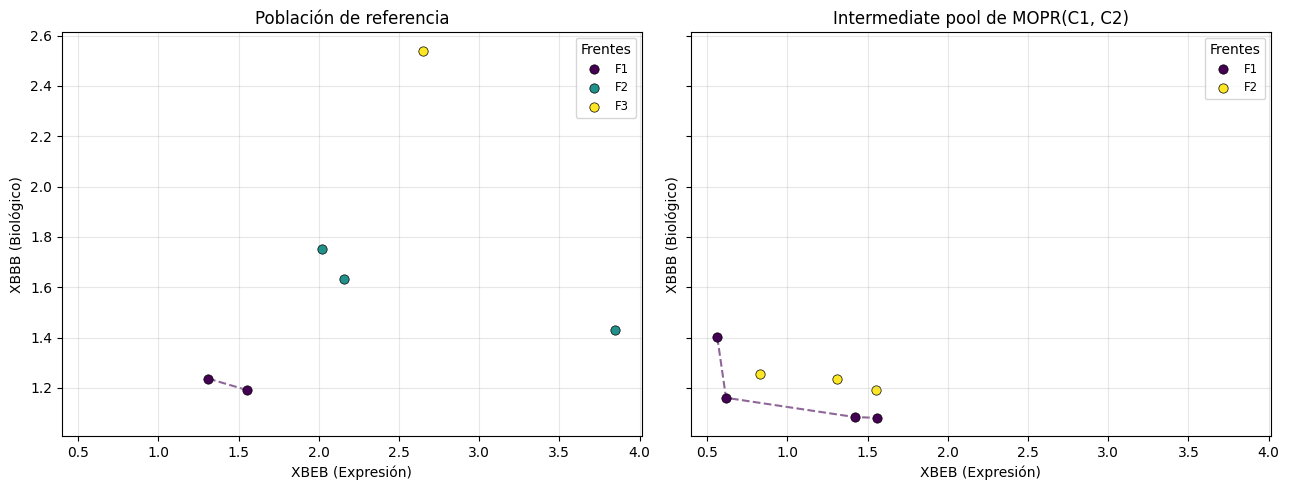

In [3]:
##################################
# Bloque de ejecución: MOPR sobre un par del frente de Pareto
##################################
K        = 4
POP_SIZE = 6
SEED     = None

ge_matrix, gene_names = load_distance_matrix(DE_DIR)
bi_matrix, _          = load_distance_matrix(DB_DIR)
n = ge_matrix.shape[0]

# ── Reinicio explícito: max_obj_calls debe contarse DESDE ESTE PUNTO,       ──
# ── no desde que arrancó el kernel (evita resultados vacíos silenciosos). ──
solution_encoding.OBJ_FUNCTION_CALLS = 0

population = random_medoids_pop(n=n, k=K, pop_size=POP_SIZE, seed=SEED)
objectives = np.array([evaluate_objectives(ind, ge_matrix, bi_matrix) for ind in population])
fronts = non_dominated_sort(objectives)

f1_idx = fronts[0]
if len(f1_idx) >= 2:
    C1, C2 = population[f1_idx[0]], population[f1_idx[1]]
else:
    C1, C2 = population[0], population[1]

print(f"n genes = {n}  |  k medoides = {K}  |  población de referencia = {POP_SIZE}\n")
print(f"Frentes de la población de referencia: {[len(f) for f in fronts]}\n")

MAX_OBJ_CALLS = 100
result = multi_objective_path_relinking(C1, C2, ge_matrix, bi_matrix, MAX_OBJ_CALLS, verbose=True)

print(f"\n[MOPR] Llamadas usadas: {solution_encoding.OBJ_FUNCTION_CALLS}/{MAX_OBJ_CALLS}")
if len(result["f1"]) == 0:
    print("[MOPR] ADVERTENCIA: F1 vacío — la cuota se agotó antes de poder evaluar el pool final.")

print(f"\n── Frente F1 resultante de MOPR({C1.tolist()}, {C2.tolist()}) ──")
for sol, (xbeb, xbbb) in zip(result["f1"], result["f1_obj"]):
    genes = [gene_names[i] for i in sol]
    print(f"  {genes}  → XBEB={xbeb:.6f}, XBBB={xbbb:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
plot_pareto_fronts_note(objectives, fronts, title="Población de referencia", ax=axes[0])

if len(result["pool_obj"]) > 0:
    pool_fronts = non_dominated_sort(result["pool_obj"])
    plot_pareto_fronts_note(np.asarray(result["pool_obj"]), pool_fronts,
                        title="Intermediate pool de MOPR(C1, C2)", ax=axes[1])
else:
    axes[1].set_title("Intermediate pool de MOPR(C1, C2) — vacío (cuota agotada)")
fig.tight_layout()
plt.show()

In [4]:
#######################################################
# run_nsga2_MOPR: variante de run_nsga2 que agrega Multi-Objective
# Path-Relinking (MOPR) como estrategia de intensificación
#######################################################

from nsga2 import (
    evaluate_population, 
    compute_ranks_and_crowding, 
    binary_tournament_selection, 
    k_point_crossover, 
    controller_random_mutation, 
    _ensure_unique
)

def evaluate_objectives(medoids: np.ndarray, ge_matrix: np.ndarray, bi_matrix: np.ndarray) -> tuple[float, float]:
    """Evalúa (XB_GE, XB_BI) para UNA sola solución de medoides (requerido por MOPR)."""
    labels = build_clusters_population(ge_matrix, medoids[None, :])[0]
    return xie_beni(ge_matrix, bi_matrix, medoids, labels)

def run_nsga2_MOPR(
    ge_matrix: np.ndarray,
    bi_matrix: np.ndarray,
    n: int,
    k: int,
    pop_size: int,
    max_obj_function_calls: int,
    crossover_prob: float = 0.80,
    mutation_prob: float = 0.01,
    seed: int | None = None,
) -> dict:
    """
    Variante de run_nsga2 que agrega MOPR como estrategia de intensificación
    (líneas 11-12 del Algoritmo 1, Parraga-Alava et al. 2018): tras construir
    Rv = Pv ∪ Qv, se extrae su frente no dominado F1, se aplica MOPR sobre
    pares consecutivos de F1, y las soluciones NUEVAS que aporta (evaluadas
    respetando la misma cuota global) se agregan de vuelta a Rv antes de la
    selección de sobrevivientes. El resto del ciclo (selección por torneo,
    crossover, mutación, truncamiento por rank+crowding) es IDÉNTICO a
    run_nsga2.

    Criterio de paro EXACTO: MOPR comparte la MISMA cuota global
    (solution_encoding.OBJ_FUNCTION_CALLS vs max_obj_function_calls) que el
    resto del ciclo, por lo que puede detener una trayectoria a medio camino
    si el presupuesto se agota (nunca se excede max_obj_function_calls).
    """
    rng = np.random.default_rng(seed)

    population = random_medoids_pop(n=n, k=k, pop_size=pop_size, seed=seed)
    population, objectives, labels_pop = evaluate_population(
        population, ge_matrix, bi_matrix, max_obj_function_calls=max_obj_function_calls,
    )

    initial_fronts = non_dominated_sort(objectives) if len(objectives) else [[]]
    initial_f1 = initial_fronts[0]

    history_objectives = [objectives.copy()]
    history_labels = [labels_pop.copy()]
    history_hv = [hypervolume_from_origin(objectives[:, 0], objectives[:, 1])] if len(objectives) else []
    history_hv_f1 = [hypervolume_from_origin(objectives[initial_f1, 0], objectives[initial_f1, 1])] if len(objectives) else []

    gen = 0
    while solution_encoding.OBJ_FUNCTION_CALLS < max_obj_function_calls and len(population) >= 2:
        gen += 1
        pop_size_actual = len(population)

        # ── Selección + offspring (idéntico a run_nsga2) ────────────────────
        ranks, crowding, _ = compute_ranks_and_crowding(objectives)
        parents = binary_tournament_selection(population, ranks, crowding, n_offspring=pop_size_actual, rng=rng)

        existing_sets = {frozenset(ind.tolist()) for ind in population}

        offspring_candidates = np.empty_like(parents)
        for i in range(0, pop_size_actual - 1, 2):
            c1, c2 = k_point_crossover(parents[i], parents[i + 1], n=n, crossover_prob=crossover_prob, rng=rng)
            c1 = controller_random_mutation(c1, n=n, mutation_prob=mutation_prob, rng=rng)
            c2 = controller_random_mutation(c2, n=n, mutation_prob=mutation_prob, rng=rng)
            offspring_candidates[i] = _ensure_unique(c1, existing_sets, n, k, rng)
            offspring_candidates[i + 1] = _ensure_unique(c2, existing_sets, n, k, rng)
        if pop_size_actual % 2 == 1:
            c_last = controller_random_mutation(parents[-1].copy(), n=n, mutation_prob=mutation_prob, rng=rng)
            offspring_candidates[-1] = _ensure_unique(c_last, existing_sets, n, k, rng)

        offspring, offspring_objectives, offspring_labels = evaluate_population(
            offspring_candidates, ge_matrix, bi_matrix, max_obj_function_calls=max_obj_function_calls,
        )
        if len(offspring) == 0:
            break

        combined_population = np.vstack([population, offspring])
        combined_objectives = np.vstack([objectives, offspring_objectives])
        combined_labels = np.vstack([labels_pop, offspring_labels])

        # ── MOPR: ÚNICO agregado respecto a run_nsga2 ───────────────────────
        # Intensificación sobre el frente no dominado de Rv = Pv ∪ Qv.
        if solution_encoding.OBJ_FUNCTION_CALLS < max_obj_function_calls:
            rv_fronts = non_dominated_sort(combined_objectives)
            f1_idx = rv_fronts[0]
            f1_pop = combined_population[f1_idx]

            if len(f1_pop) >= 2:
                pooled = [f1_pop]
                for i in range(len(f1_pop) - 1):
                    if solution_encoding.OBJ_FUNCTION_CALLS >= max_obj_function_calls:
                        break
                    C1, C2 = f1_pop[i], f1_pop[i + 1]
                    if frozenset(C1.tolist()) == frozenset(C2.tolist()):
                        continue
                    mopr_result = multi_objective_path_relinking(
                        C1, C2, ge_matrix, bi_matrix, max_obj_function_calls, verbose=False,
                    )
                    if len(mopr_result["f1"]) > 0:
                        pooled.append(mopr_result["f1"])

                mopr_pop = np.vstack(pooled)
                seen = set()
                unique_rows = []
                for sol in mopr_pop:
                    key = frozenset(sol.tolist())
                    if key not in seen:
                        seen.add(key)
                        unique_rows.append(sol)
                mopr_pop = np.stack(unique_rows)

                # Solo evaluar (y agregar) las soluciones REALMENTE nuevas
                # que MOPR aportó — evita recalcular objetivos ya conocidos.
                existing_keys = {frozenset(sol.tolist()) for sol in combined_population}
                new_rows = [sol for sol in mopr_pop if frozenset(sol.tolist()) not in existing_keys]
                if new_rows:
                    new_solutions = np.stack(new_rows)
                    new_solutions, new_objectives, new_labels = evaluate_population(
                        new_solutions, ge_matrix, bi_matrix, max_obj_function_calls=max_obj_function_calls,
                    )
                    if len(new_solutions) > 0:
                        combined_population = np.vstack([combined_population, new_solutions])
                        combined_objectives = np.vstack([combined_objectives, new_objectives])
                        combined_labels = np.vstack([combined_labels, new_labels])

        # ── Selección de sobrevivientes (idéntica a run_nsga2) ──────────────
        _, combined_crowding, combined_fronts = compute_ranks_and_crowding(combined_objectives)

        target_size = min(pop_size, len(combined_population))
        next_indices: list[int] = []
        for front in combined_fronts:
            if len(next_indices) + len(front) <= target_size:
                next_indices.extend(front)
            else:
                remaining_slots = target_size - len(next_indices)
                front_sorted = sorted(front, key=lambda idx: combined_crowding[idx], reverse=True)
                next_indices.extend(front_sorted[:remaining_slots])
                break

        population = combined_population[next_indices]
        objectives = combined_objectives[next_indices]
        labels_pop = combined_labels[next_indices]

        current_fronts = non_dominated_sort(objectives)
        f1_indices = current_fronts[0]
        f1_hv = hypervolume_from_origin(objectives[f1_indices, 0], objectives[f1_indices, 1])

        history_objectives.append(objectives.copy())
        history_labels.append(labels_pop.copy())
        history_hv.append(hypervolume_from_origin(objectives[:, 0], objectives[:, 1]))
        history_hv_f1.append(f1_hv)

        mean_hv = np.mean(history_hv[-1])
        mean_hv_f1 = np.mean(f1_hv)
        print(
            f"[gen {gen:>3}] llamadas = {solution_encoding.OBJ_FUNCTION_CALLS:>6}/{max_obj_function_calls}  |  "
            f"población = {len(population)}  |  F1 = {len(f1_indices)}  |  "
            f"HV promedio = {mean_hv:.6f}  |  HV F1 promedio = {mean_hv_f1:.6f}"
        )

    print(f"\nCriterio de paro EXACTO: {solution_encoding.OBJ_FUNCTION_CALLS}/{max_obj_function_calls} llamadas a la función objetivo, {gen} generaciones completadas.")

    return {
        "population": population,
        "objectives": objectives,
        "labels": labels_pop,
        "fronts": non_dominated_sort(objectives),
        "history_objectives": history_objectives,
        "history_labels": history_labels,
        "history_hv": history_hv,
        "history_hv_mean": [float(np.mean(hv)) for hv in history_hv],
        "history_hv_f1": history_hv_f1,
        "history_hv_f1_mean": [float(np.mean(hv)) for hv in history_hv_f1],
        "generations_run": gen,
    }

[gen   1] llamadas =    432/6000  |  población = 30  |  F1 = 6  |  HV promedio = 1.585461  |  HV F1 promedio = 0.804143
[gen   2] llamadas =    761/6000  |  población = 30  |  F1 = 8  |  HV promedio = 0.818201  |  HV F1 promedio = 0.547179
[gen   3] llamadas =   1057/6000  |  población = 30  |  F1 = 10  |  HV promedio = 0.758386  |  HV F1 promedio = 0.593321
[gen   4] llamadas =   1419/6000  |  población = 30  |  F1 = 6  |  HV promedio = 0.632834  |  HV F1 promedio = 0.611701
[gen   5] llamadas =   1534/6000  |  población = 30  |  F1 = 8  |  HV promedio = 0.614611  |  HV F1 promedio = 0.576238
[gen   6] llamadas =   1652/6000  |  población = 30  |  F1 = 8  |  HV promedio = 0.624851  |  HV F1 promedio = 0.576238
[gen   7] llamadas =   1769/6000  |  población = 30  |  F1 = 8  |  HV promedio = 0.624851  |  HV F1 promedio = 0.576238
[gen   8] llamadas =   1887/6000  |  población = 30  |  F1 = 8  |  HV promedio = 0.618729  |  HV F1 promedio = 0.576238
[gen   9] llamadas =   2005/6000  |  po

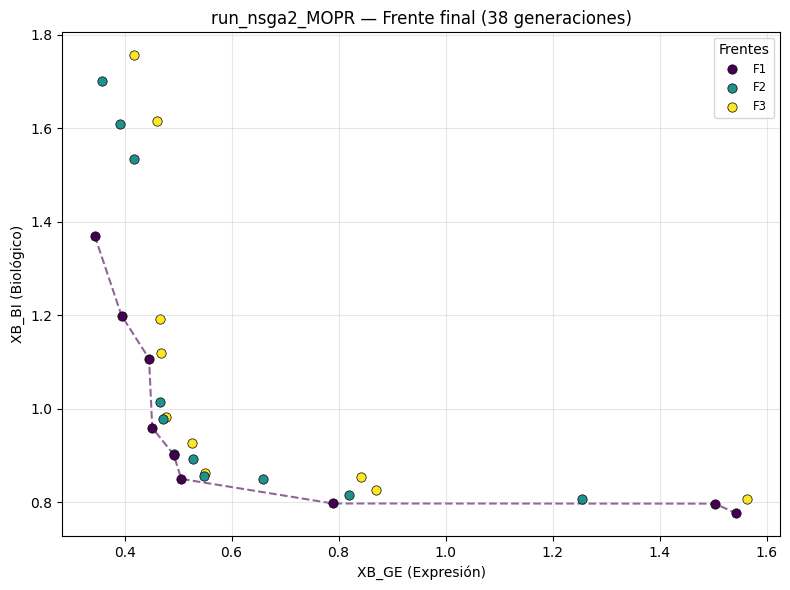

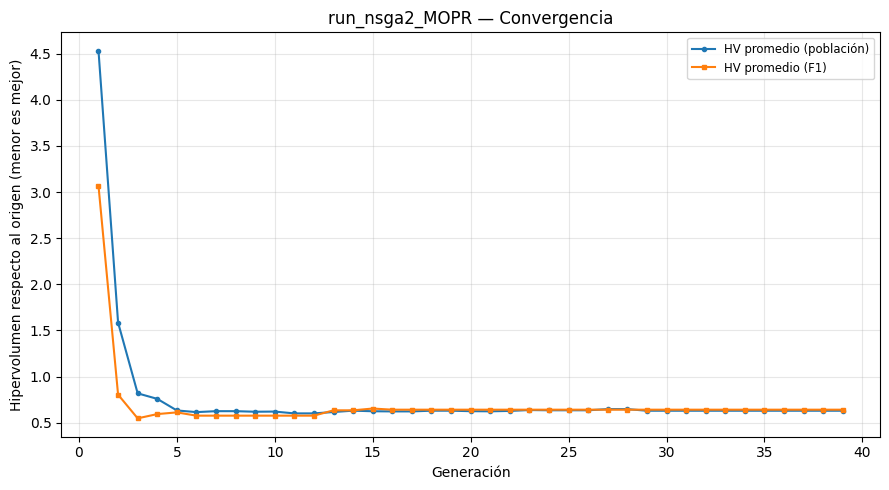

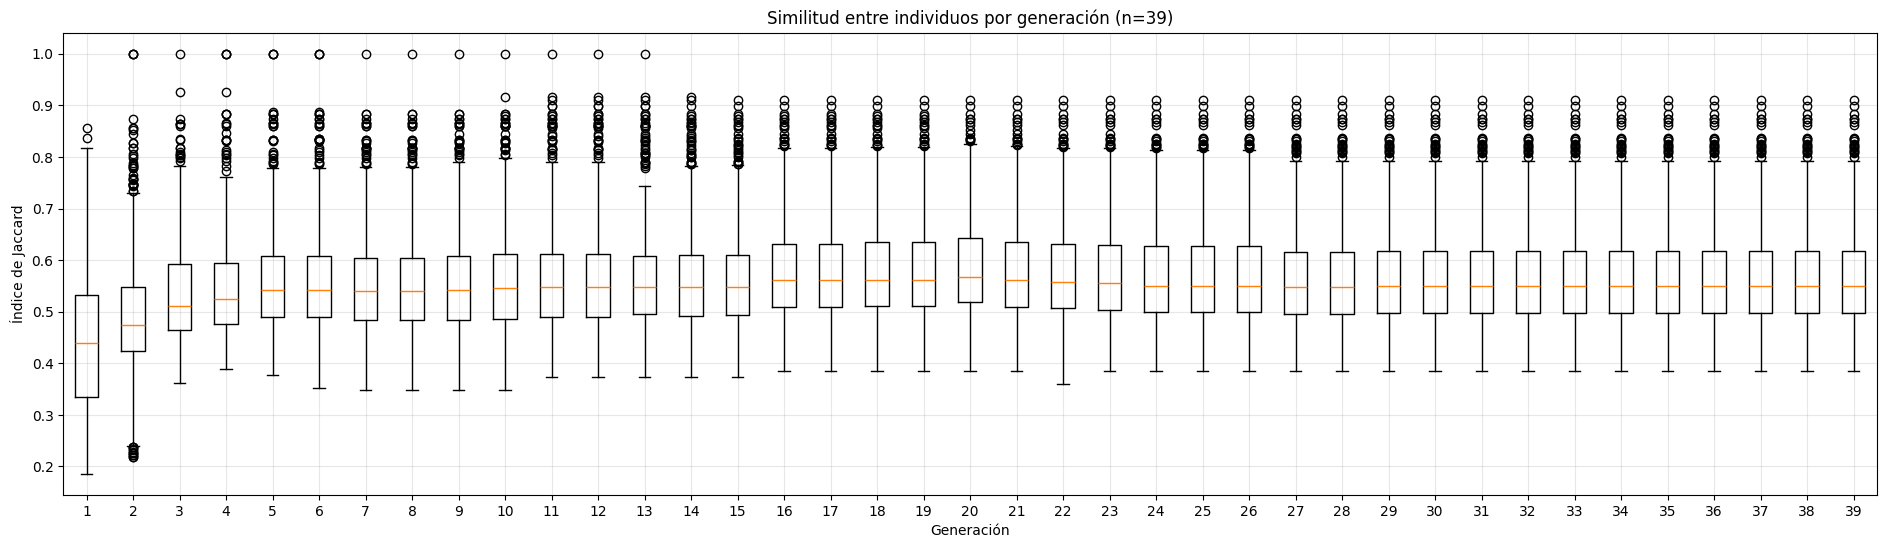


── Frente F1 final ──
  ['TTYH2', 'PLCE1', 'JRKL', 'HM13']  → XBEB=0.394426, XBBB=1.198771
  ['RPP40', 'PLCE1', 'TMEM62', 'SPATS2']  → XBEB=0.789130, XBBB=0.797284
  ['RPP40', 'PLCE1', 'TMEM62', 'CAPN12']  → XBEB=1.503374, XBBB=0.796969
  ['TTYH2', 'PLCE1', 'CAPN12', 'RPP40']  → XBEB=0.445729, XBBB=1.106949
  ['TTYH2', 'ULK2', 'CAPN12', 'RPP40']  → XBEB=0.491860, XBBB=0.901682
  ['CDC42EP5', 'ULK2', 'CAPN12', 'RPP40']  → XBEB=0.451712, XBBB=0.958963
  ['RPP40', 'GLT8D2', 'TRIM46', 'MROH6']  → XBEB=1.542365, XBBB=0.776502
  ['RPP40', 'PLCE1', 'TRIM46', 'LY86']  → XBEB=0.505854, XBBB=0.849827
  ['PCNA', 'PLCE1', 'TRIM46', 'LY86']  → XBEB=0.344132, XBBB=1.369724


In [5]:
##################################
# Bloque de ejecución/testeo: run_nsga2_MOPR completo
##################################
K                      = 4       # número de clusters (medoides por individuo)
POP_SIZE               = 30      # tamaño de la población
MAX_OBJ_FUNCTION_CALLS = 6000    # presupuesto total de evaluaciones (cuota GLOBAL)
CROSSOVER_PROB         = 0.80
MUTATION_PROB          = 0.05
SEED                   = None

# ── Reinicio explícito del contador global ──────────────────────────────────
# (obligatorio: MAX_OBJ_FUNCTION_CALLS se compara contra
# solution_encoding.OBJ_FUNCTION_CALLS, que es acumulativo entre celdas)
solution_encoding.OBJ_FUNCTION_CALLS = 0

result_mopr = run_nsga2_MOPR(
    ge_matrix, bi_matrix,
    n=n, k=K, pop_size=POP_SIZE,
    max_obj_function_calls=MAX_OBJ_FUNCTION_CALLS,
    crossover_prob=CROSSOVER_PROB, mutation_prob=MUTATION_PROB, seed=SEED,
)

##################################
# Resultados por pantalla
##################################
assert solution_encoding.OBJ_FUNCTION_CALLS <= MAX_OBJ_FUNCTION_CALLS, "SE EXCEDIÓ LA CUOTA GLOBAL"

print(f"\nGeneraciones ejecutadas       : {result_mopr['generations_run']}")
print(f"Llamadas a función objetivo   : {solution_encoding.OBJ_FUNCTION_CALLS}/{MAX_OBJ_FUNCTION_CALLS}")
print(f"Frentes en población final    : {len(result_mopr['fronts'])}")
print(f"F1 (no dominado)              : {len(result_mopr['fronts'][0])} soluciones")

f1_idx_final = result_mopr["fronts"][0]
f1_obj_final = result_mopr["objectives"][f1_idx_final]
print(f"Mejor XBEB en F1              : {f1_obj_final[:, 0].min():.6f}")
print(f"Mejor XBBB en F1              : {f1_obj_final[:, 1].min():.6f}")

# ── Frente de Pareto final ───────────────────────────────────────────────
plot_pareto_fronts(
    result_mopr["objectives"], result_mopr["fronts"],
    title=f"run_nsga2_MOPR — Frente final ({result_mopr['generations_run']} generaciones)",
    show=True
)

# ── Convergencia: hipervolumen promedio por generación (población y F1) ──
gens = np.arange(1, len(result_mopr["history_hv_f1_mean"]) + 1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(gens, result_mopr["history_hv_mean"], marker="o", markersize=3, label="HV promedio (población)")
ax.plot(gens, result_mopr["history_hv_f1_mean"], marker="s", markersize=3, label="HV promedio (F1)")
ax.set_xlabel("Generación")
ax.set_ylabel("Hipervolumen respecto al origen (menor es mejor)")
ax.set_title("run_nsga2_MOPR — Convergencia")
ax.legend(loc="best", fontsize="small")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# ── Diversidad: índice de Jaccard entre individuos por generación ────────
_ = jaccard_population(result_mopr["history_labels"])

print("\n── Frente F1 final ──")
for idx in f1_idx_final:
    genes = [gene_names[i] for i in result_mopr["population"][idx]]
    xbeb, xbbb = result_mopr["objectives"][idx]
    print(f"  {genes}  → XBEB={xbeb:.6f}, XBBB={xbbb:.6f}")

## Pareto Local Search (PLS)

<div style="text-align: justify;">

El enfoque de diversificación de _PLS_ se basa exclusivamente en la generación de vecindarios bajo la premisa de reemplazar **un medoide, elegido al azar, por cada uno de los candidatos que no están presentes en la solución actual**. Esto permite expandir el espacio de exploración basándose en pequeños cambios dentro de $F_1$ [1]. Cabe señalar que, dada la naturaleza de este operador, al tratarse de una metaheurística dentro de otra, el número de iteraciones disponibles y de llamadas a la función objetivo es un elemento sensible dentro de este trabajo.

</div>

<div align="center">

![Medoides](Gráficos/PLS.png)
  <figcaption style="font-size: 0.9em; color: #FFF; margin-top: 8px; text-align: justify;">
    <strong>Figura 2.</strong> Pareto Local Search (Imagen extraída del paper de Parraga-Alava) [1]. <br>
  </figcaption>
<br>

</div>

In [6]:
#######################################################
# MODULO PARETO LOCAL SEARCH (PLS)
#######################################################

def generate_neighborhood(
    C: np.ndarray,
    n: int,
    rng: np.random.Generator,
) -> tuple[list[np.ndarray], int, int]:
    """
    Genera el vecindario N(C) de una solución, reemplazando un medoide
    elegido al azar por cada elemento del dataset aún no presente en C.

    Retorna
    -------
    neighbors : list[np.ndarray] — |N(C)| = n - k vecinos.
    pos       : int — posición del cromosoma modificada.
    zk        : int — medoide original en esa posición.
    """
    k = len(C)                          # Número de medoides.
    pos = int(rng.integers(0, k))       # Se toma un elemento a reemplazar.
    zk = int(C[pos])                    # Medoide a reemplazar.

    # Medoides usados y lista de medoides posibles para remplazo.
    used = set(C.tolist())
    candidates_z = [z for z in range(n) if z not in used]

    # Generación de vecindario.
    neighbors = []
    for zl in candidates_z:
        neighbor = C.copy()
        neighbor[pos] = zl
        neighbors.append(neighbor)

    return neighbors, pos, zk

#######################################################
# CORRECCIÓN: PLS ya no re-evalúa objetivos que el llamador ya conoce
#######################################################

def pareto_local_search(
    initial_population: np.ndarray,
    ge_matrix: np.ndarray,
    bi_matrix: np.ndarray,
    max_obj_calls: int,
    initial_objectives: np.ndarray | None = None,
    local_budget: int | None = None,
    seed: int | None = None,
    verbose: bool = False,
) -> tuple[np.ndarray, list[tuple[float, float]]]:
    """
    Aplica Pareto Local Search (PLS), respetando cuota GLOBAL + LOCAL.

    Parámetros
    ----------
    initial_objectives : np.ndarray | None — objetivos (XBEB, XBBB) YA
        CONOCIDOS para `initial_population`, en el mismo orden y shape
        (m, 2). Si se proveen, NO se vuelve a llamar evaluate_objectives
        sobre esas soluciones — evita gastar presupuesto re-confirmando
        algo que el llamador ya calculó (p.ej. el F1 de Rv en
        run_nsga2_PLS, ya evaluado por evaluate_population/xie_beni; o el
        F1 de MOPR en local_search_step). Si es None (comportamiento
        anterior), se evalúan todas desde cero, consumiendo
        len(initial_population) llamadas antes de explorar un solo vecino.
    """
    rng = np.random.default_rng(seed)
    n = ge_matrix.shape[0]

    calls_start = solution_encoding.OBJ_FUNCTION_CALLS
    local_cap = (calls_start + local_budget) if local_budget is not None else max_obj_calls
    effective_max = min(max_obj_calls, local_cap)

    if initial_objectives is not None and len(initial_objectives) != len(initial_population):
        raise ValueError(
            f"'initial_objectives' ({len(initial_objectives)}) debe tener el mismo "
            f"largo que 'initial_population' ({len(initial_population)})."
        )

    pool: dict[frozenset, dict] = {}
    for idx, sol in enumerate(initial_population):
        key = frozenset(sol.tolist())
        if key in pool:
            continue
        if initial_objectives is not None:
            # Objetivo YA CONOCIDO por el llamador: no se gasta presupuesto.
            obj = tuple(initial_objectives[idx])
        else:
            if solution_encoding.OBJ_FUNCTION_CALLS >= effective_max:
                break
            obj = evaluate_objectives(sol, ge_matrix, bi_matrix)
        pool[key] = {"solution": sol.copy(), "objectives": obj, "explored": False}

    if verbose:
        print(f"[PLS] Población inicial A0: {len(pool)} soluciones "
              f"(llamadas={solution_encoding.OBJ_FUNCTION_CALLS}/{effective_max}, "
              f"objetivos_precalculados={initial_objectives is not None}).")

    while True:
        if solution_encoding.OBJ_FUNCTION_CALLS >= effective_max:
            if verbose:
                reason = "cuota LOCAL de esta llamada" if effective_max < max_obj_calls else "cuota GLOBAL"
                print(f"[PLS] {reason} agotada ({solution_encoding.OBJ_FUNCTION_CALLS}/{effective_max}). Deteniendo.")
            break

        unexplored_keys = [key for key, entry in pool.items() if not entry["explored"]]
        if not unexplored_keys:
            if verbose:
                print(f"[PLS] A0 vacía. Población final |A|={len(pool)}.")
            break

        # ── 1. Selección ────────────────────────────────────────────────────
        c_key = unexplored_keys[int(rng.integers(0, len(unexplored_keys)))]
        C = pool[c_key]["solution"]
        C_obj = pool[c_key]["objectives"]

        # ── 2. Exploración de vecindad ──────────────────────────────────────
        neighbors, pos, zk = generate_neighborhood(C, n, rng)

        remaining = effective_max - solution_encoding.OBJ_FUNCTION_CALLS
        if remaining <= 0:
            break
        if len(neighbors) > remaining:
            neighbors = neighbors[:remaining]

        if verbose:
            print(f"[PLS] C={C.tolist()}  (XBEB={C_obj[0]:.4f}, XBBB={C_obj[1]:.4f})  "
                  f"reemplazando posición {pos} (z_{zk}), |N(C)|={len(neighbors)}")

        # ── 3. Criterio de aceptación (dominancia) ──────────────────────────
        for neighbor in neighbors:
            neighbor_key = frozenset(neighbor.tolist())
            neighbor_obj = evaluate_objectives(neighbor, ge_matrix, bi_matrix)

            if not _dominates(C_obj, neighbor_obj):
                if neighbor_key not in pool:
                    pool[neighbor_key] = {"solution": neighbor, "objectives": neighbor_obj, "explored": False}
                dominated_keys = [
                    key for key, entry in pool.items()
                    if key != neighbor_key and _dominates(neighbor_obj, entry["objectives"])
                ]
                for key in dominated_keys:
                    del pool[key]

        if c_key in pool:
            pool[c_key]["explored"] = True

    if not pool:
        k = initial_population.shape[1]
        return np.empty((0, k), dtype=initial_population.dtype), []

    population = np.stack([entry["solution"] for entry in pool.values()])
    objectives = [entry["objectives"] for entry in pool.values()]
    return population, objectives

Población de entrada a PLS (F1 de MOPR): 4 soluciones.
Población final de PLS                 : 9 soluciones (llamadas=800/800).



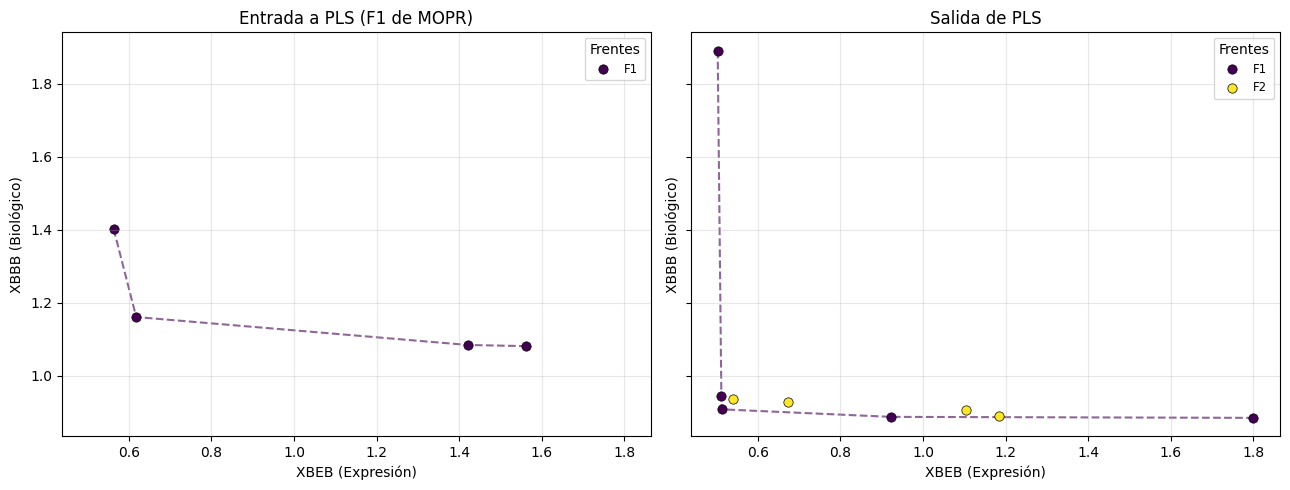

── Frente F1 tras PLS ──
  ['GLB1L2', 'CRYAB', 'HSD17B6', 'TYMS']  → XBEB=0.502875, XBBB=1.890239
  ['GLB1L2', 'DOCK9', 'HSD17B6', 'TYMS']  → XBEB=0.921795, XBBB=0.887331
  ['GLB1L2', 'PCDHGA12', 'HSD17B6', 'TYMS']  → XBEB=0.511770, XBBB=0.944408
  ['GLB1L2', 'LIFR', 'HSD17B6', 'TYMS']  → XBEB=1.799525, XBBB=0.884576
  ['GLB1L2', 'RARRES2', 'HSD17B6', 'TYMS']  → XBEB=0.512528, XBBB=0.907948


In [7]:
##################################
# Bloque de ejecución/testeo: PLS sobre el F1 resultante de MOPR
# (ACTUALIZADO: usa max_obj_calls/local_budget en vez de max_iterations)
##################################
MAX_OBJ_CALLS_PLS = 800    # cuota GLOBAL para esta demo
LOCAL_BUDGET_PLS  = None   # demo standalone: puede usar todo MAX_OBJ_CALLS_PLS
                           # (dentro de run_nsga2_PLS habría que fijar un
                           # número, para que PLS no se coma toda la cuota
                           # de una sola generación — ver corrección anterior)

# Reinicio explícito: esta celda se trata como demo autocontenida de PLS
# partiendo del F1 de MOPR, no como continuación de la cuota gastada por
# la celda anterior (evita resultados chicos/vacíos por arrastre de cuota).
solution_encoding.OBJ_FUNCTION_CALLS = 0

pls_pop, pls_obj_list = pareto_local_search(
    initial_population=result["f1"],
    ge_matrix=ge_matrix, bi_matrix=bi_matrix,
    max_obj_calls=MAX_OBJ_CALLS_PLS, local_budget=LOCAL_BUDGET_PLS,
    seed=SEED, verbose=False,
)
pls_obj = np.asarray(pls_obj_list, dtype=np.float64) if len(pls_obj_list) else np.empty((0, 2))
pls_fronts = non_dominated_sort(pls_obj) if len(pls_obj) else []

##################################
# Resultados por pantalla
##################################
print(f"Población de entrada a PLS (F1 de MOPR): {len(result['f1'])} soluciones.")
print(f"Población final de PLS                 : {pls_pop.shape[0]} soluciones "
      f"(llamadas={solution_encoding.OBJ_FUNCTION_CALLS}/{MAX_OBJ_CALLS_PLS}).\n")
assert solution_encoding.OBJ_FUNCTION_CALLS <= MAX_OBJ_CALLS_PLS, "SE EXCEDIÓ LA CUOTA GLOBAL"

if pls_pop.shape[0] == 0:
    print("ADVERTENCIA: PLS no generó ninguna solución — la cuota ya estaba agotada "
          "antes de poder evaluar el F1 de entrada.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
    mopr_f1_fronts = [list(range(len(result["f1_obj"])))]
    plot_pareto_fronts_note(np.asarray(result["f1_obj"]), mopr_f1_fronts,
                        title="Entrada a PLS (F1 de MOPR)", ax=axes[0])
    plot_pareto_fronts_note(pls_obj, pls_fronts, title="Salida de PLS", ax=axes[1])
    fig.tight_layout()
    plt.show()

    print("── Frente F1 tras PLS ──")
    for idx in pls_fronts[0]:
        sol, (xbeb, xbbb) = pls_pop[idx], pls_obj[idx]
        genes = [gene_names[i] for i in sol]
        print(f"  {genes}  → XBEB={xbeb:.6f}, XBBB={xbbb:.6f}")

In [8]:
#######################################################
# run_nsga2_PLS: variante de run_nsga2 que agrega Pareto Local Search
# (PLS) como estrategia de diversificación
#######################################################

def run_nsga2_PLS(
    ge_matrix: np.ndarray,
    bi_matrix: np.ndarray,
    n: int,
    k: int,
    pop_size: int,
    max_obj_function_calls: int,
    crossover_prob: float = 0.80,
    mutation_prob: float = 0.01,
    pls_local_budget: int | None = None,
    seed: int | None = None,
) -> dict:
    """
    Variante de run_nsga2 que agrega PLS como estrategia de diversificación
    (líneas 13-14 del Algoritmo 1, Parraga-Alava et al. 2018): tras construir
    Rv = Pv ∪ Qv, se extrae su frente no dominado F1 y se aplica PLS sobre
    él; las soluciones NUEVAS que aporta se agregan de vuelta a Rv antes de
    la selección de sobrevivientes. El resto del ciclo es IDÉNTICO a
    run_nsga2 — MOPR no se agrega en esta variante.

    Parámetros
    ----------
    pls_local_budget : int | None — cuota de evaluaciones que PLS puede
        consumir POR GENERACIÓN (ver corrección de pareto_local_search).
        SIN este límite, PLS puede agotar TODO max_obj_function_calls en
        la primera generación, dejando 0 evaluaciones para el resto del
        NSGA-II (comprobado: con pop_size=20, max_obj_function_calls=3000,
        sin límite el run termina en 1 generación; con
        pls_local_budget=150 —5% del total— corre 18 generaciones
        completas). Se recomienda fijarlo como una fracción de
        max_obj_function_calls, análogo al parámetro `ls_budget` de
        Toledo (2021), Sección 3.3.6.

    Criterio de paro EXACTO: PLS comparte la MISMA cuota global
    (solution_encoding.OBJ_FUNCTION_CALLS vs max_obj_function_calls) que el
    resto del ciclo — nunca se excede max_obj_function_calls.
    """
    rng = np.random.default_rng(seed)

    population = random_medoids_pop(n=n, k=k, pop_size=pop_size, seed=seed)
    population, objectives, labels_pop = evaluate_population(
        population, ge_matrix, bi_matrix, max_obj_function_calls=max_obj_function_calls,
    )

    initial_fronts = non_dominated_sort(objectives) if len(objectives) else [[]]
    initial_f1 = initial_fronts[0]

    history_objectives = [objectives.copy()]
    history_labels = [labels_pop.copy()]
    history_hv = [hypervolume_from_origin(objectives[:, 0], objectives[:, 1])] if len(objectives) else []
    history_hv_f1 = [hypervolume_from_origin(objectives[initial_f1, 0], objectives[initial_f1, 1])] if len(objectives) else []

    gen = 0
    while solution_encoding.OBJ_FUNCTION_CALLS < max_obj_function_calls and len(population) >= 2:
        gen += 1
        pop_size_actual = len(population)

        # ── Selección + offspring (idéntico a run_nsga2) ────────────────────
        ranks, crowding, _ = compute_ranks_and_crowding(objectives)
        parents = binary_tournament_selection(population, ranks, crowding, n_offspring=pop_size_actual, rng=rng)

        existing_sets = {frozenset(ind.tolist()) for ind in population}

        offspring_candidates = np.empty_like(parents)
        for i in range(0, pop_size_actual - 1, 2):
            c1, c2 = k_point_crossover(parents[i], parents[i + 1], n=n, crossover_prob=crossover_prob, rng=rng)
            c1 = controller_random_mutation(c1, n=n, mutation_prob=mutation_prob, rng=rng)
            c2 = controller_random_mutation(c2, n=n, mutation_prob=mutation_prob, rng=rng)
            offspring_candidates[i] = _ensure_unique(c1, existing_sets, n, k, rng)
            offspring_candidates[i + 1] = _ensure_unique(c2, existing_sets, n, k, rng)
        if pop_size_actual % 2 == 1:
            c_last = controller_random_mutation(parents[-1].copy(), n=n, mutation_prob=mutation_prob, rng=rng)
            offspring_candidates[-1] = _ensure_unique(c_last, existing_sets, n, k, rng)

        offspring, offspring_objectives, offspring_labels = evaluate_population(
            offspring_candidates, ge_matrix, bi_matrix, max_obj_function_calls=max_obj_function_calls,
        )
        if len(offspring) == 0:
            break

        combined_population = np.vstack([population, offspring])
        combined_objectives = np.vstack([objectives, offspring_objectives])
        combined_labels = np.vstack([labels_pop, offspring_labels])

        # ── PLS: ÚNICO agregado respecto a run_nsga2 ────────────────────────
        # Diversificación sobre el frente no dominado de Rv = Pv ∪ Qv.
        if solution_encoding.OBJ_FUNCTION_CALLS < max_obj_function_calls:
            rv_fronts = non_dominated_sort(combined_objectives)
            f1_idx = rv_fronts[0]
            f1_pop = combined_population[f1_idx]

            if len(f1_pop) >= 1:
                pls_pop, pls_obj_list = pareto_local_search(
                    initial_population=f1_pop,
                    initial_objectives=combined_objectives[f1_idx],
                    ge_matrix=ge_matrix, bi_matrix=bi_matrix,
                    max_obj_calls=max_obj_function_calls,
                    local_budget=pls_local_budget,
                    seed=int(rng.integers(0, 2**31 - 1)),
                    verbose=False,
                )

                if len(pls_pop) > 0:
                    # Solo agregar las soluciones REALMENTE nuevas que PLS
                    # descubrió (evita duplicar lo que ya estaba en Rv).
                    existing_keys = {frozenset(sol.tolist()) for sol in combined_population}
                    new_mask = np.array([frozenset(sol.tolist()) not in existing_keys for sol in pls_pop])
                    if new_mask.any():
                        new_solutions = pls_pop[new_mask]
                        new_objectives = np.asarray(pls_obj_list, dtype=np.float64)[new_mask]
                        # Los objetivos YA fueron evaluados dentro de PLS
                        # (no volver a llamar xie_beni/evaluate_population,
                        # eso duplicaría el gasto de cuota); solo se
                        # recalculan las asignaciones de cluster, que no
                        # consumen presupuesto.
                        new_labels = build_clusters_population(ge_matrix, new_solutions)

                        combined_population = np.vstack([combined_population, new_solutions])
                        combined_objectives = np.vstack([combined_objectives, new_objectives])
                        combined_labels = np.vstack([combined_labels, new_labels])

        # ── Selección de sobrevivientes (idéntica a run_nsga2) ──────────────
        _, combined_crowding, combined_fronts = compute_ranks_and_crowding(combined_objectives)

        target_size = min(pop_size, len(combined_population))
        next_indices: list[int] = []
        for front in combined_fronts:
            if len(next_indices) + len(front) <= target_size:
                next_indices.extend(front)
            else:
                remaining_slots = target_size - len(next_indices)
                front_sorted = sorted(front, key=lambda idx: combined_crowding[idx], reverse=True)
                next_indices.extend(front_sorted[:remaining_slots])
                break

        population = combined_population[next_indices]
        objectives = combined_objectives[next_indices]
        labels_pop = combined_labels[next_indices]

        current_fronts = non_dominated_sort(objectives)
        f1_indices = current_fronts[0]
        f1_hv = hypervolume_from_origin(objectives[f1_indices, 0], objectives[f1_indices, 1])

        history_objectives.append(objectives.copy())
        history_labels.append(labels_pop.copy())
        history_hv.append(hypervolume_from_origin(objectives[:, 0], objectives[:, 1]))
        history_hv_f1.append(f1_hv)

        mean_hv = np.mean(history_hv[-1])
        mean_hv_f1 = np.mean(f1_hv)
        print(
            f"[gen {gen:>3}] llamadas = {solution_encoding.OBJ_FUNCTION_CALLS:>6}/{max_obj_function_calls}  |  "
            f"población = {len(population)}  |  F1 = {len(f1_indices)}  |  "
            f"HV promedio = {mean_hv:.6f}  |  HV F1 promedio = {mean_hv_f1:.6f}"
        )

    print(f"\nCriterio de paro EXACTO: {solution_encoding.OBJ_FUNCTION_CALLS}/{max_obj_function_calls} llamadas a la función objetivo, {gen} generaciones completadas.")

    return {
        "population": population,
        "objectives": objectives,
        "labels": labels_pop,
        "fronts": non_dominated_sort(objectives),
        "history_objectives": history_objectives,
        "history_labels": history_labels,
        "history_hv": history_hv,
        "history_hv_mean": [float(np.mean(hv)) for hv in history_hv],
        "history_hv_f1": history_hv_f1,
        "history_hv_f1_mean": [float(np.mean(hv)) for hv in history_hv_f1],
        "generations_run": gen,
    }

[gen   1] llamadas =    360/6000  |  población = 30  |  F1 = 5  |  HV promedio = 1.722520  |  HV F1 promedio = 1.542694
[gen   2] llamadas =    690/6000  |  población = 30  |  F1 = 6  |  HV promedio = 1.302720  |  HV F1 promedio = 1.638594
[gen   3] llamadas =   1020/6000  |  población = 30  |  F1 = 6  |  HV promedio = 1.142883  |  HV F1 promedio = 0.482432
[gen   4] llamadas =   1350/6000  |  población = 30  |  F1 = 12  |  HV promedio = 1.267453  |  HV F1 promedio = 1.991329
[gen   5] llamadas =   1680/6000  |  población = 30  |  F1 = 8  |  HV promedio = 1.143057  |  HV F1 promedio = 0.486564
[gen   6] llamadas =   2010/6000  |  población = 30  |  F1 = 7  |  HV promedio = 1.223039  |  HV F1 promedio = 0.491959
[gen   7] llamadas =   2340/6000  |  población = 30  |  F1 = 8  |  HV promedio = 0.581137  |  HV F1 promedio = 0.471456
[gen   8] llamadas =   2670/6000  |  población = 30  |  F1 = 9  |  HV promedio = 0.560484  |  HV F1 promedio = 0.440925
[gen   9] llamadas =   3000/6000  |  po

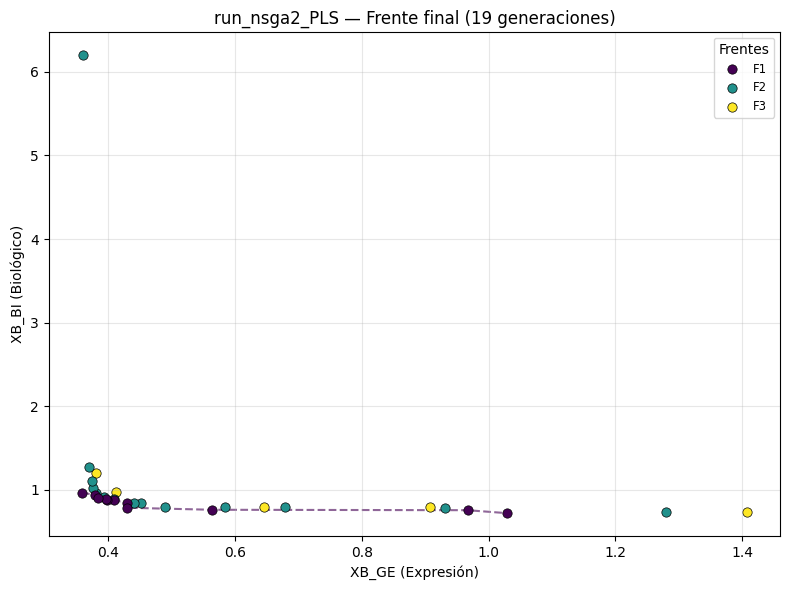

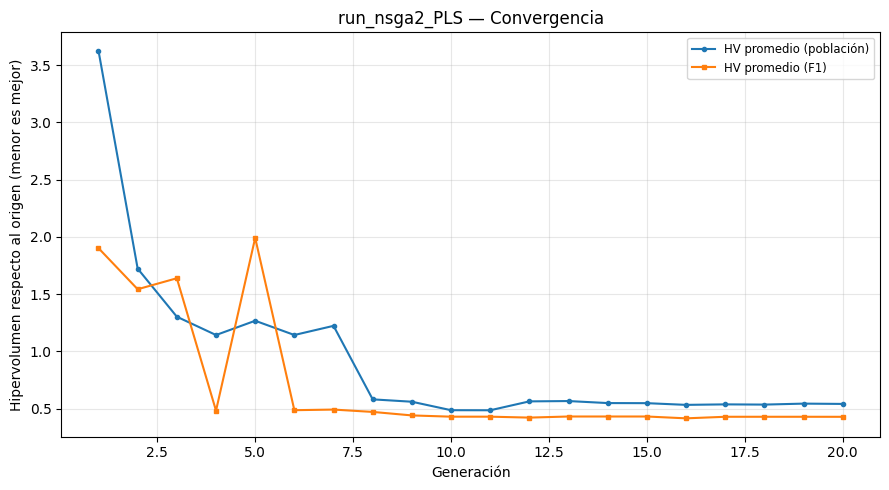

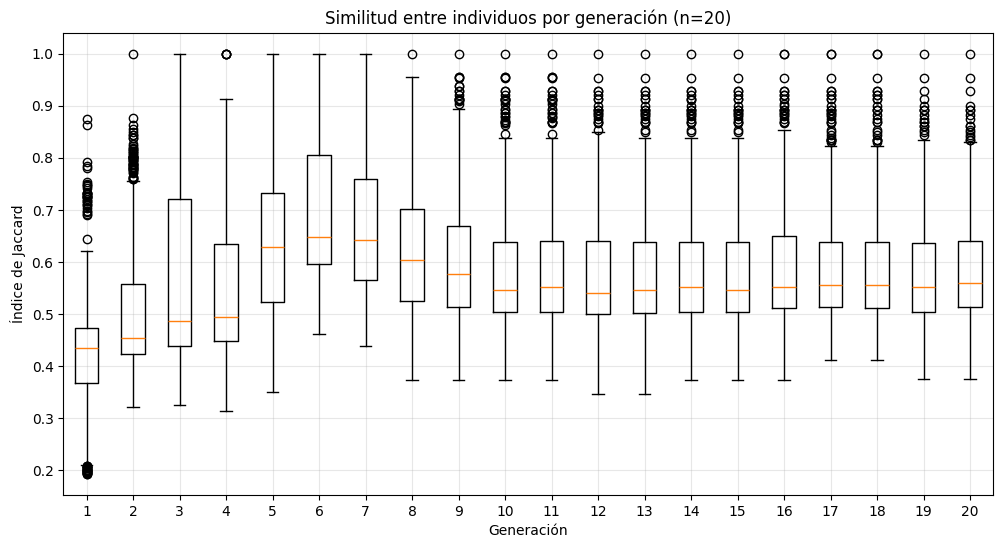


── Frente F1 final ──
  ['RGS9BP', 'CAPN12', 'R3HDM1', 'EBF1']  → XBEB=0.409145, XBBB=0.873650
  ['RGS9BP', 'GLB1L2', 'R3HDM1', 'EBF1']  → XBEB=0.397552, XBBB=0.879890
  ['SLC39A8', 'CAPN12', 'R3HDM1', 'EBF1']  → XBEB=0.396456, XBBB=0.894498
  ['SLC39A8', 'MROH6', 'R3HDM1', 'EBF1']  → XBEB=0.379707, XBBB=0.936557
  ['SLC39A8', 'GLB1L2', 'R3HDM1', 'EBF1']  → XBEB=0.384041, XBBB=0.900738
  ['HSD17B6', 'GLB1L2', 'R3HDM1', 'EBF1']  → XBEB=0.358494, XBBB=0.968525
  ['SLC39A8', 'CAPN12', 'CILP2', 'EBF1']  → XBEB=0.429601, XBBB=0.845828
  ['SLC39A8', 'CAPN12', 'CILP2', 'PIMREG']  → XBEB=1.029615, XBBB=0.721321
  ['SLC39A8', 'CAPN12', 'ZNF22-AS1', 'PIMREG']  → XBEB=0.966930, XBBB=0.757016
  ['SLC39A8', 'CAPN12', 'FMOD', 'PIMREG']  → XBEB=0.564001, XBBB=0.762156
  ['RGS9BP', 'CAPN12', 'R3HDM1', 'MEF2D']  → XBEB=0.429968, XBBB=0.786180


In [9]:
##################################
# Bloque de ejecución/testeo: run_nsga2_PLS completo
##################################
K                      = 4       # número de clusters (medoides por individuo)
POP_SIZE               = 30      # tamaño de la población
MAX_OBJ_FUNCTION_CALLS = 6000    # presupuesto total de evaluaciones (cuota GLOBAL)
PLS_LOCAL_BUDGET       = MAX_OBJ_FUNCTION_CALLS // 20   # 5% del total por generación
CROSSOVER_PROB         = 0.80
MUTATION_PROB          = 0.05
SEED                   = None

# ── Reinicio explícito del contador global ──────────────────────────────────
solution_encoding.OBJ_FUNCTION_CALLS = 0

result_pls = run_nsga2_PLS(
    ge_matrix, bi_matrix,
    n=n, k=K, pop_size=POP_SIZE,
    max_obj_function_calls=MAX_OBJ_FUNCTION_CALLS,
    crossover_prob=CROSSOVER_PROB, mutation_prob=MUTATION_PROB,
    pls_local_budget=PLS_LOCAL_BUDGET, seed=SEED,
)

##################################
# Resultados por pantalla
##################################
assert solution_encoding.OBJ_FUNCTION_CALLS <= MAX_OBJ_FUNCTION_CALLS, "SE EXCEDIÓ LA CUOTA GLOBAL"
assert result_pls["generations_run"] > 1, "ADVERTENCIA: PLS se comió todo el presupuesto en 1 generación — revisar PLS_LOCAL_BUDGET"

print(f"\nGeneraciones ejecutadas       : {result_pls['generations_run']}")
print(f"Llamadas a función objetivo   : {solution_encoding.OBJ_FUNCTION_CALLS}/{MAX_OBJ_FUNCTION_CALLS}")
print(f"Frentes en población final    : {len(result_pls['fronts'])}")
print(f"F1 (no dominado)              : {len(result_pls['fronts'][0])} soluciones")

f1_idx_final = result_pls["fronts"][0]
f1_obj_final = result_pls["objectives"][f1_idx_final]
print(f"Mejor XBEB en F1              : {f1_obj_final[:, 0].min():.6f}")
print(f"Mejor XBBB en F1              : {f1_obj_final[:, 1].min():.6f}")

# ── Frente de Pareto final ───────────────────────────────────────────────
plot_pareto_fronts(
    result_pls["objectives"], result_pls["fronts"],
    title=f"run_nsga2_PLS — Frente final ({result_pls['generations_run']} generaciones)",
    show=True
)

# ── Convergencia: hipervolumen promedio por generación (población y F1) ──
gens = np.arange(1, len(result_pls["history_hv_f1_mean"]) + 1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(gens, result_pls["history_hv_mean"], marker="o", markersize=3, label="HV promedio (población)")
ax.plot(gens, result_pls["history_hv_f1_mean"], marker="s", markersize=3, label="HV promedio (F1)")
ax.set_xlabel("Generación")
ax.set_ylabel("Hipervolumen respecto al origen (menor es mejor)")
ax.set_title("run_nsga2_PLS — Convergencia")
ax.legend(loc="best", fontsize="small")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# ── Diversidad: índice de Jaccard entre individuos por generación ────────
_ = jaccard_population(result_pls["history_labels"])

print("\n── Frente F1 final ──")
for idx in f1_idx_final:
    genes = [gene_names[i] for i in result_pls["population"][idx]]
    xbeb, xbbb = result_pls["objectives"][idx]
    print(f"  {genes}  → XBEB={xbeb:.6f}, XBBB={xbbb:.6f}")

## N-MOLS y L-MOLS

<div style="text-align: justify;">

En el trabajo de Mariangel (2020) se presentan numerosos operadores y fuentes de información biológica para abordar puntos pendientes del trabajo de Parraga-Alava (2018). Entre los distintos operadores considerados, se optó por N-MOLS y L-MOLS por dos razones particulares: **su implementación resulta prácticamente "2x1", al ser casi idénticos entre sí, además de que L-MOLS figuró entre los operadores de mejor rendimiento junto con _PLS_**. En consecuencia, resulta conveniente incorporar estos operadores para aportar variedad a las comparaciones.

</div>

<div align="center">

![Medoides](Gráficos/LMOLS.png)
  <figcaption style="font-size: 0.9em; color: #FFF; margin-top: 8px; text-align: justify;">
    <strong>Figura 3.</strong> LMOLS (Imagen extraída del trabajo de Mariangel) [2]. <br>
  </figcaption>
<br>

</div>

<div align="center">

![Medoides](Gráficos/NMOLS.png)
  <figcaption style="font-size: 0.9em; color: #FFF; margin-top: 8px; text-align: justify;">
    <strong>Figura 4.</strong> NMOLS (Imagen extraída del trabajo de Mariangel) [2]. <br>
  </figcaption>
<br>

</div>

In [10]:
#######################################################
# MODULO N-MOLS / L-MOLS — CORREGIDO
# (cuota global+local, dominancia vectorizada, sin re-evaluación redundante)
#######################################################

def build_neighborhood_matrix(ge_matrix: np.ndarray, bi_matrix: np.ndarray) -> np.ndarray:
    """Matriz de vecindario M_V (ecuación 3.3, Toledo 2021) = sqrt(GE² + BI²)."""
    return np.sqrt(ge_matrix ** 2 + bi_matrix ** 2)

def generate_neighborhood_mols(
    C: np.ndarray,
    m_v_matrix: np.ndarray,
    neighborhood: float,
) -> list[np.ndarray]:
    """Neighborhood(C, M_V) según ecuación 3.4: un medoide reemplazado por
    un gen no presente con M_V(reemplazado, reemplazo) <= neighborhood."""
    k = len(C)                  # Medoides.
    used = set(C.tolist())      # Medoides utilizados.
    neighbors = []              # Vecindario.

    # Por cada posición dentro del arreglo de medoides se verifican los
    # genes más cercanos al medoide a reemplazar según el parametro neighborhood.
    # Evitando que esta sea igual al gen que se esta cambiando y que ya
    # sea parte de la solución.
    for pos in range(k):
        zk = int(C[pos])
        close_genes = np.where(m_v_matrix[zk] <= neighborhood)[0]
        for zl in close_genes:
            zl = int(zl)
            if zl == zk or zl in used:
                continue
            neighbor = C.copy()
            neighbor[pos] = zl
            neighbors.append(neighbor)

    # Retorno de vecindario.
    return neighbors

def _dominates_vec(a: np.ndarray, B: np.ndarray) -> np.ndarray:
    """True donde 'a' domina a B[i] (minimización). a:(2,), B:(m,2)."""
    a = np.asarray(a, dtype=np.float64)
    B = np.asarray(B, dtype=np.float64)
    not_worse = np.all(a <= B, axis=1)
    strictly_better = np.any(a < B, axis=1)
    return not_worse & strictly_better

def _is_dominated_by_vec(a: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Inverso de _dominates_vec: True donde B[i] domina a 'a'."""
    a = np.asarray(a, dtype=np.float64)
    B = np.asarray(B, dtype=np.float64)
    not_worse = np.all(B <= a, axis=1)
    strictly_better = np.any(B < a, axis=1)
    return not_worse & strictly_better

def _mols_search(
    population: np.ndarray,
    ge_matrix: np.ndarray,
    bi_matrix: np.ndarray,
    m_v_matrix: np.ndarray,
    neighborhood: float,
    max_obj_calls: int,
    mode: str,
    population_objectives: np.ndarray | None = None,
    local_budget: int | None = None,
    verbose: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Núcleo compartido de L-MOLS y N-MOLS (Algoritmos 3.6 y 3.7, Toledo 2021).

    Parámetros
    ----------
    max_obj_calls : int — cuota GLOBAL del run completo (contra
        solution_encoding.OBJ_FUNCTION_CALLS).
    population_objectives : np.ndarray | None — objetivos (XBEB, XBBB) YA
        CONOCIDOS para `population`, en el mismo orden (shape (m,2)). Evita
        re-evaluar (y re-gastar presupuesto) soluciones cuyo objetivo el
        llamador ya calculó (p.ej. el F1 de Rv en run_nsga2_MOLS).
    local_budget : int | None — cuota propia de ESTA llamada (análogo a
        pareto_local_search); evita que una invocación dentro del ciclo de
        NSGA-II consuma TODO el presupuesto restante de una vez.
    """
    assert mode in ("l_mols", "n_mols"), "mode debe ser 'l_mols' o 'n_mols'."
    if population_objectives is not None and len(population_objectives) != len(population):
        raise ValueError(
            f"'population_objectives' ({len(population_objectives)}) debe tener el mismo "
            f"largo que 'population' ({len(population)})."
        )

    calls_start = solution_encoding.OBJ_FUNCTION_CALLS
    local_cap = (calls_start + local_budget) if local_budget is not None else max_obj_calls
    effective_max = min(max_obj_calls, local_cap)

    archive: list[np.ndarray] = []
    archive_obj: list[np.ndarray] = []
    seen = {frozenset(sol.tolist()) for sol in population}

    for idx, solution in enumerate(population):
        if population_objectives is not None:
            solution_obj = np.asarray(population_objectives[idx], dtype=np.float64)
        else:
            if solution_encoding.OBJ_FUNCTION_CALLS >= effective_max:
                break
            solution_obj = np.asarray(evaluate_objectives(solution, ge_matrix, bi_matrix), dtype=np.float64)

        neighbors = generate_neighborhood_mols(solution, m_v_matrix, neighborhood)
        neighbors = [nb for nb in neighbors if frozenset(nb.tolist()) not in seen]

        remaining = effective_max - solution_encoding.OBJ_FUNCTION_CALLS
        if remaining <= 0:
            break
        if len(neighbors) > remaining:
            neighbors = neighbors[:remaining]
        if not neighbors:
            continue

        neighbor_objs = np.array([evaluate_objectives(nb, ge_matrix, bi_matrix) for nb in neighbors])

        if mode == "l_mols":
            accept_mask = ~_dominates_vec(solution_obj, neighbor_objs)
        else:
            accept_mask = _is_dominated_by_vec(solution_obj, neighbor_objs)

        for nb, nb_obj, accepted in zip(neighbors, neighbor_objs, accept_mask):
            if accepted:
                key = frozenset(nb.tolist())
                if key not in seen:
                    archive.append(nb)
                    archive_obj.append(nb_obj)
                    seen.add(key)

        if verbose:
            print(f"[MOLS] solución {solution.tolist()} → archive acumulado: {len(archive)} "
                  f"(llamadas: {solution_encoding.OBJ_FUNCTION_CALLS}/{effective_max})")

    if not archive:
        return np.empty((0, population.shape[1]), dtype=population.dtype), np.empty((0, 2))

    return np.stack(archive), np.asarray(archive_obj, dtype=np.float64)


def l_mols(
    population: np.ndarray, ge_matrix: np.ndarray, bi_matrix: np.ndarray,
    m_v_matrix: np.ndarray, neighborhood: float, max_obj_calls: int,
    population_objectives: np.ndarray | None = None,
    local_budget: int | None = None, verbose: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    """Large-MOLS (Algoritmo 3.6): acepta un vecino si la solución NO lo domina (no-dominación)."""
    return _mols_search(population, ge_matrix, bi_matrix, m_v_matrix, neighborhood,
                         max_obj_calls, mode="l_mols", population_objectives=population_objectives,
                         local_budget=local_budget, verbose=verbose)

def n_mols(
    population: np.ndarray, ge_matrix: np.ndarray, bi_matrix: np.ndarray,
    m_v_matrix: np.ndarray, neighborhood: float, max_obj_calls: int,
    population_objectives: np.ndarray | None = None,
    local_budget: int | None = None, verbose: bool = False,
) -> tuple[np.ndarray, np.ndarray]:
    """Narrow-MOLS (Algoritmo 3.7): acepta un vecino solo si DOMINA a la solución (dominación)."""
    return _mols_search(population, ge_matrix, bi_matrix, m_v_matrix, neighborhood,
                         max_obj_calls, mode="n_mols", population_objectives=population_objectives,
                         local_budget=local_budget, verbose=verbose)

M_V → min=0.0681  p5=0.5365  max=1.2952
L-MOLS → archive de 372 soluciones (llamadas=454/500).
N-MOLS → archive de 119 soluciones (llamadas=454/500).


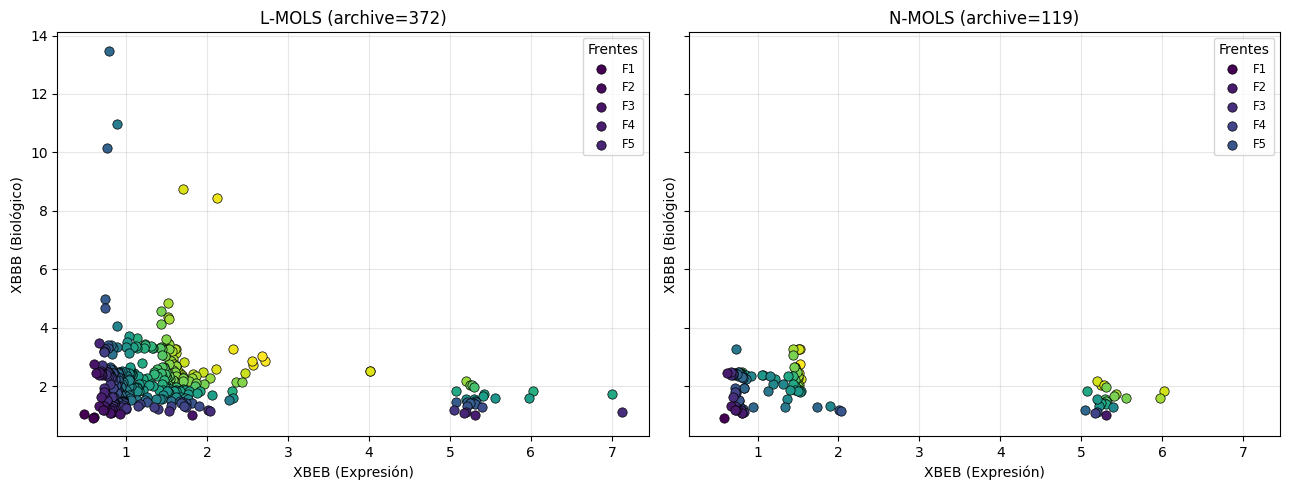

In [11]:
##################################
# Bloque de ejecución/testeo: L-MOLS vs N-MOLS
##################################
solution_encoding.OBJ_FUNCTION_CALLS = 0

m_v_matrix = build_neighborhood_matrix(ge_matrix, bi_matrix)
iu = np.triu_indices_from(m_v_matrix, k=1)
mv_values = m_v_matrix[iu]
NEIGHBORHOOD = float(np.percentile(mv_values, 5))
MAX_OBJ_CALLS = 500

test_pop = random_medoids_pop(n=n, k=K, pop_size=8, seed=SEED)
test_obj = np.array([evaluate_objectives(ind, ge_matrix, bi_matrix) for ind in test_pop])

print(f"M_V → min={mv_values.min():.4f}  p5={NEIGHBORHOOD:.4f}  max={mv_values.max():.4f}")

solution_encoding.OBJ_FUNCTION_CALLS = 0
l_pop, l_obj = l_mols(test_pop, ge_matrix, bi_matrix, m_v_matrix, NEIGHBORHOOD,
                       max_obj_calls=MAX_OBJ_CALLS, population_objectives=test_obj)
print(f"L-MOLS → archive de {l_pop.shape[0]} soluciones (llamadas={solution_encoding.OBJ_FUNCTION_CALLS}/{MAX_OBJ_CALLS}).")

solution_encoding.OBJ_FUNCTION_CALLS = 0
n_pop, n_obj = n_mols(test_pop, ge_matrix, bi_matrix, m_v_matrix, NEIGHBORHOOD,
                       max_obj_calls=MAX_OBJ_CALLS, population_objectives=test_obj)
print(f"N-MOLS → archive de {n_pop.shape[0]} soluciones (llamadas={solution_encoding.OBJ_FUNCTION_CALLS}/{MAX_OBJ_CALLS}).")

l_fronts = non_dominated_sort(l_obj) if len(l_obj) else [[]]
n_fronts = non_dominated_sort(n_obj) if len(n_obj) else [[]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
plot_pareto_fronts_note(l_obj, l_fronts, title=f"L-MOLS (archive={l_pop.shape[0]})", ax=axes[0])
plot_pareto_fronts_note(n_obj, n_fronts, title=f"N-MOLS (archive={n_pop.shape[0]})", ax=axes[1])
fig.tight_layout()
plt.show()

In [12]:
#######################################################
# run_nsga2_MOLS: variante de run_nsga2 que agrega N-MOLS o L-MOLS
# (según `mode`) como estrategia de búsqueda local
#######################################################

def run_nsga2_MOLS(
    ge_matrix: np.ndarray,
    bi_matrix: np.ndarray,
    n: int,
    k: int,
    pop_size: int,
    max_obj_function_calls: int,
    mode: str,
    neighborhood: float,
    crossover_prob: float = 0.80,
    mutation_prob: float = 0.01,
    mols_local_budget: int | None = None,
    seed: int | None = None,
) -> dict:
    """
    Variante de run_nsga2 que agrega L-MOLS o N-MOLS (Haidine & Lehnert,
    2008; Toledo 2021) como estrategia de búsqueda local: tras construir
    Rv = Pv ∪ Qv, se extrae su frente no dominado F1 y se aplica el
    operador elegido (`mode`); las soluciones NUEVAS se agregan de vuelta
    a Rv antes de la selección de sobrevivientes. Resto del ciclo idéntico
    a run_nsga2 — MOPR/PLS no se agregan en esta variante.

    Parámetros
    ----------
    mode                : "l_mols" | "n_mols".
    neighborhood        : float — radio de vecindario (parámetro del
                          algoritmo, ver Sección 3.3.6 de Toledo).
    mols_local_budget   : int | None — cuota POR GENERACIÓN para MOLS (ver
                          corrección de pareto_local_search/run_nsga2_PLS
                          — sin esto, MOLS puede consumir TODO el
                          presupuesto en una sola generación).

    Criterio de paro EXACTO: MOLS comparte la MISMA cuota global
    (solution_encoding.OBJ_FUNCTION_CALLS vs max_obj_function_calls).
    """
    assert mode in ("l_mols", "n_mols"), "mode debe ser 'l_mols' o 'n_mols'."
    mols_fn = l_mols if mode == "l_mols" else n_mols

    # M_V es estática (no depende de la población) -> se calcula UNA sola vez.
    m_v_matrix = build_neighborhood_matrix(ge_matrix, bi_matrix)

    rng = np.random.default_rng(seed)

    population = random_medoids_pop(n=n, k=k, pop_size=pop_size, seed=seed)
    population, objectives, labels_pop = evaluate_population(
        population, ge_matrix, bi_matrix, max_obj_function_calls=max_obj_function_calls,
    )

    initial_fronts = non_dominated_sort(objectives) if len(objectives) else [[]]
    initial_f1 = initial_fronts[0]

    history_objectives = [objectives.copy()]
    history_labels = [labels_pop.copy()]
    history_hv = [hypervolume_from_origin(objectives[:, 0], objectives[:, 1])] if len(objectives) else []
    history_hv_f1 = [hypervolume_from_origin(objectives[initial_f1, 0], objectives[initial_f1, 1])] if len(objectives) else []

    gen = 0
    while solution_encoding.OBJ_FUNCTION_CALLS < max_obj_function_calls and len(population) >= 2:
        gen += 1
        pop_size_actual = len(population)

        # ── Selección + offspring (idéntico a run_nsga2) ────────────────────
        ranks, crowding, _ = compute_ranks_and_crowding(objectives)
        parents = binary_tournament_selection(population, ranks, crowding, n_offspring=pop_size_actual, rng=rng)

        existing_sets = {frozenset(ind.tolist()) for ind in population}

        offspring_candidates = np.empty_like(parents)
        for i in range(0, pop_size_actual - 1, 2):
            c1, c2 = k_point_crossover(parents[i], parents[i + 1], n=n, crossover_prob=crossover_prob, rng=rng)
            c1 = controller_random_mutation(c1, n=n, mutation_prob=mutation_prob, rng=rng)
            c2 = controller_random_mutation(c2, n=n, mutation_prob=mutation_prob, rng=rng)
            offspring_candidates[i] = _ensure_unique(c1, existing_sets, n, k, rng)
            offspring_candidates[i + 1] = _ensure_unique(c2, existing_sets, n, k, rng)
        if pop_size_actual % 2 == 1:
            c_last = controller_random_mutation(parents[-1].copy(), n=n, mutation_prob=mutation_prob, rng=rng)
            offspring_candidates[-1] = _ensure_unique(c_last, existing_sets, n, k, rng)

        offspring, offspring_objectives, offspring_labels = evaluate_population(
            offspring_candidates, ge_matrix, bi_matrix, max_obj_function_calls=max_obj_function_calls,
        )
        if len(offspring) == 0:
            break

        combined_population = np.vstack([population, offspring])
        combined_objectives = np.vstack([objectives, offspring_objectives])
        combined_labels = np.vstack([labels_pop, offspring_labels])

        # ── MOLS: ÚNICO agregado respecto a run_nsga2 ───────────────────────
        if solution_encoding.OBJ_FUNCTION_CALLS < max_obj_function_calls:
            rv_fronts = non_dominated_sort(combined_objectives)
            f1_idx = rv_fronts[0]
            f1_pop = combined_population[f1_idx]

            if len(f1_pop) >= 1:
                mols_pop, mols_obj = mols_fn(
                    f1_pop, ge_matrix, bi_matrix, m_v_matrix, neighborhood,
                    max_obj_calls=max_obj_function_calls,
                    population_objectives=combined_objectives[f1_idx],
                    local_budget=mols_local_budget,
                    verbose=False,
                )

                if len(mols_pop) > 0:
                    existing_keys = {frozenset(sol.tolist()) for sol in combined_population}
                    new_mask = np.array([frozenset(sol.tolist()) not in existing_keys for sol in mols_pop])
                    if new_mask.any():
                        new_solutions = mols_pop[new_mask]
                        new_objectives = mols_obj[new_mask]
                        new_labels = build_clusters_population(ge_matrix, new_solutions)

                        combined_population = np.vstack([combined_population, new_solutions])
                        combined_objectives = np.vstack([combined_objectives, new_objectives])
                        combined_labels = np.vstack([combined_labels, new_labels])

        # ── Selección de sobrevivientes (idéntica a run_nsga2) ──────────────
        _, combined_crowding, combined_fronts = compute_ranks_and_crowding(combined_objectives)

        target_size = min(pop_size, len(combined_population))
        next_indices: list[int] = []
        for front in combined_fronts:
            if len(next_indices) + len(front) <= target_size:
                next_indices.extend(front)
            else:
                remaining_slots = target_size - len(next_indices)
                front_sorted = sorted(front, key=lambda idx: combined_crowding[idx], reverse=True)
                next_indices.extend(front_sorted[:remaining_slots])
                break

        population = combined_population[next_indices]
        objectives = combined_objectives[next_indices]
        labels_pop = combined_labels[next_indices]

        current_fronts = non_dominated_sort(objectives)
        f1_indices = current_fronts[0]
        f1_hv = hypervolume_from_origin(objectives[f1_indices, 0], objectives[f1_indices, 1])

        history_objectives.append(objectives.copy())
        history_labels.append(labels_pop.copy())
        history_hv.append(hypervolume_from_origin(objectives[:, 0], objectives[:, 1]))
        history_hv_f1.append(f1_hv)

        mean_hv = np.mean(history_hv[-1])
        mean_hv_f1 = np.mean(f1_hv)
        print(
            f"[gen {gen:>3}] llamadas = {solution_encoding.OBJ_FUNCTION_CALLS:>6}/{max_obj_function_calls}  |  "
            f"población = {len(population)}  |  F1 = {len(f1_indices)}  |  "
            f"HV promedio = {mean_hv:.6f}  |  HV F1 promedio = {mean_hv_f1:.6f}"
        )

    print(f"\nCriterio de paro EXACTO: {solution_encoding.OBJ_FUNCTION_CALLS}/{max_obj_function_calls} llamadas a la función objetivo, {gen} generaciones completadas.")

    return {
        "population": population,
        "objectives": objectives,
        "labels": labels_pop,
        "fronts": non_dominated_sort(objectives),
        "history_objectives": history_objectives,
        "history_labels": history_labels,
        "history_hv": history_hv,
        "history_hv_mean": [float(np.mean(hv)) for hv in history_hv],
        "history_hv_f1": history_hv_f1,
        "history_hv_f1_mean": [float(np.mean(hv)) for hv in history_hv_f1],
        "generations_run": gen,
    }

[gen   1] llamadas =    229/6000  |  población = 30  |  F1 = 9  |  HV promedio = 0.864385  |  HV F1 promedio = 0.816740
[gen   2] llamadas =    559/6000  |  población = 30  |  F1 = 8  |  HV promedio = 0.737111  |  HV F1 promedio = 0.666011
[gen   3] llamadas =    889/6000  |  población = 30  |  F1 = 9  |  HV promedio = 0.584055  |  HV F1 promedio = 0.543814
[gen   4] llamadas =   1219/6000  |  población = 30  |  F1 = 12  |  HV promedio = 0.591825  |  HV F1 promedio = 0.576574
[gen   5] llamadas =   1549/6000  |  población = 30  |  F1 = 12  |  HV promedio = 0.559098  |  HV F1 promedio = 0.527736
[gen   6] llamadas =   1879/6000  |  población = 30  |  F1 = 14  |  HV promedio = 0.565080  |  HV F1 promedio = 0.532802
[gen   7] llamadas =   2209/6000  |  población = 30  |  F1 = 15  |  HV promedio = 0.571307  |  HV F1 promedio = 0.543322
[gen   8] llamadas =   2539/6000  |  población = 30  |  F1 = 16  |  HV promedio = 0.584732  |  HV F1 promedio = 0.549264
[gen   9] llamadas =   2869/6000  |

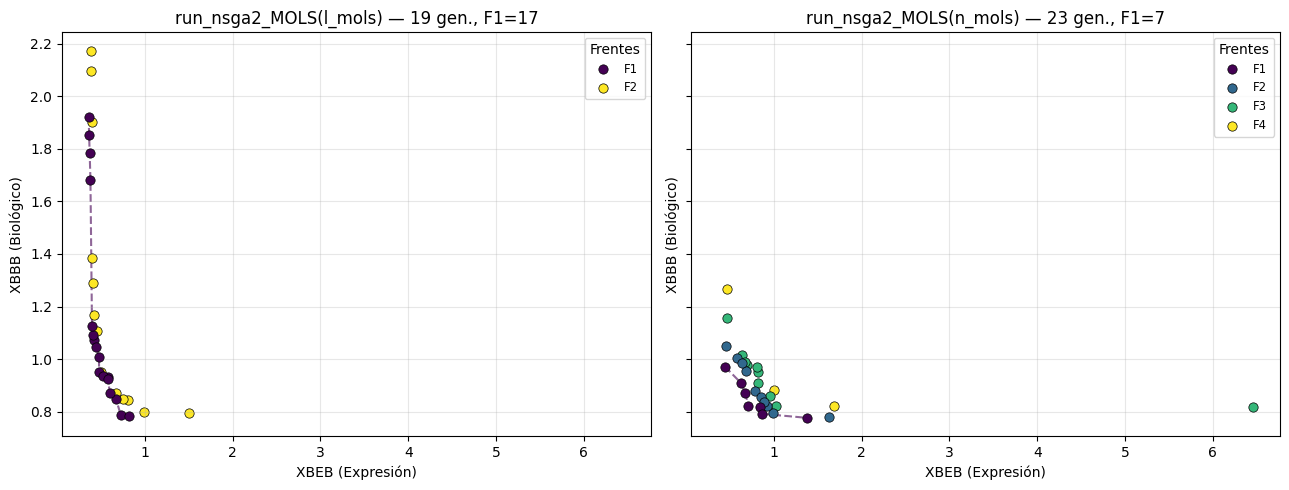

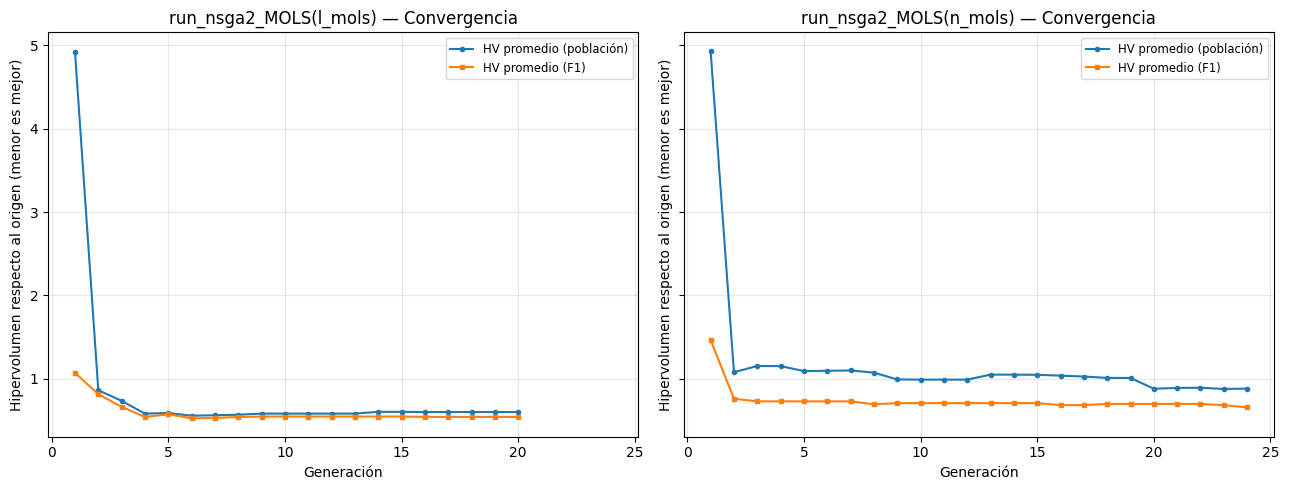

── L_MOLS ──


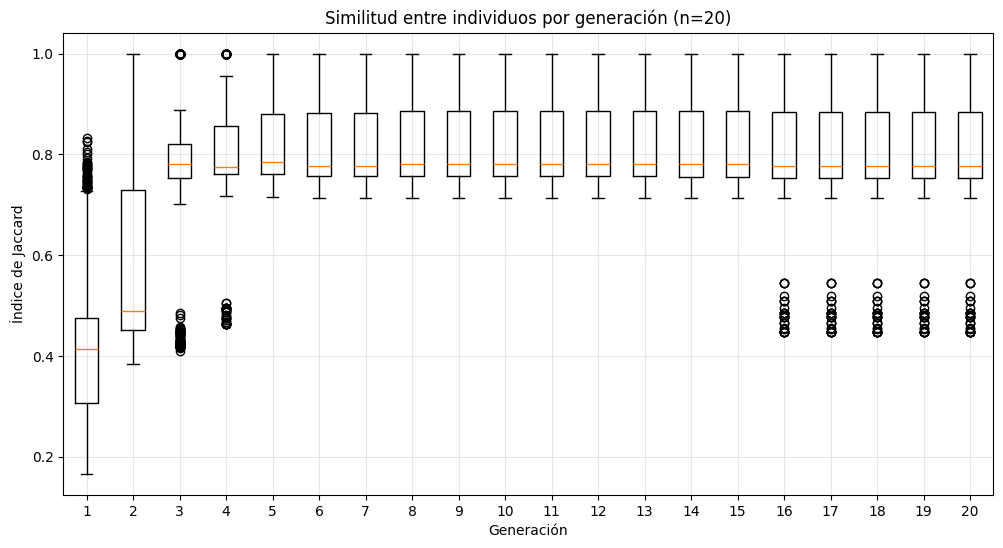

── N_MOLS ──


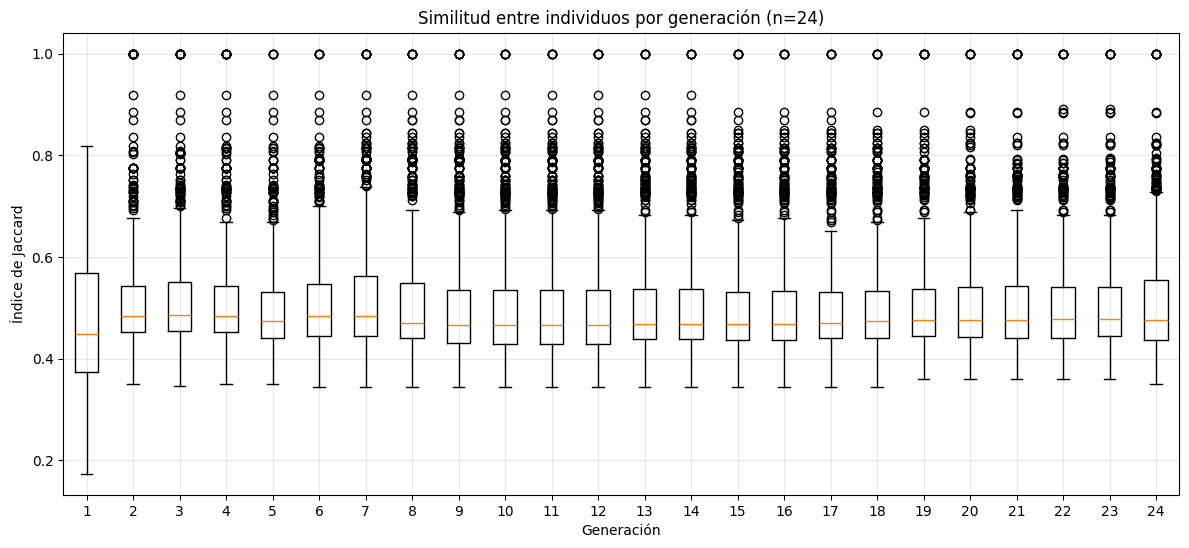


── L_MOLS ──
Generaciones: 19  |  F1 final: 17
HV F1 final: 0.545285

── N_MOLS ──
Generaciones: 23  |  F1 final: 7
HV F1 final: 0.658267


In [13]:
##################################
# Bloque de ejecución/testeo: run_nsga2_MOLS (L-MOLS y N-MOLS)
##################################
K                      = 4
POP_SIZE               = 30
MAX_OBJ_FUNCTION_CALLS = 6000
MOLS_LOCAL_BUDGET      = MAX_OBJ_FUNCTION_CALLS // 20   # 5% por generación
CROSSOVER_PROB         = 0.80
MUTATION_PROB          = 0.05
SEED                   = None

m_v_matrix = build_neighborhood_matrix(ge_matrix, bi_matrix)
iu = np.triu_indices_from(m_v_matrix, k=1)
NEIGHBORHOOD = float(np.percentile(m_v_matrix[iu], 5))

resultados_mols = {}
for mode in ("l_mols", "n_mols"):
    solution_encoding.OBJ_FUNCTION_CALLS = 0
    resultados_mols[mode] = run_nsga2_MOLS(
        ge_matrix, bi_matrix, n=n, k=K, pop_size=POP_SIZE,
        max_obj_function_calls=MAX_OBJ_FUNCTION_CALLS,
        mode=mode, neighborhood=NEIGHBORHOOD,
        crossover_prob=CROSSOVER_PROB, mutation_prob=MUTATION_PROB,
        mols_local_budget=MOLS_LOCAL_BUDGET, seed=SEED,
    )
    assert solution_encoding.OBJ_FUNCTION_CALLS <= MAX_OBJ_FUNCTION_CALLS
    assert resultados_mols[mode]["generations_run"] > 1, f"{mode} se comió todo el presupuesto en 1 generación"

##################################
# Resultados por pantalla
##################################
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, mode in zip(axes, ("l_mols", "n_mols")):
    res = resultados_mols[mode]
    plot_pareto_fronts_note(res["objectives"], res["fronts"],
                        title=f"run_nsga2_MOLS({mode}) — {res['generations_run']} gen., F1={len(res['fronts'][0])}",
                        ax=ax)
fig.tight_layout()
plt.show()

# ── Convergencia: hipervolumen promedio por generación (población y F1) ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, mode in zip(axes, ("l_mols", "n_mols")):
    res = resultados_mols[mode]
    gens = np.arange(1, len(res["history_hv_f1_mean"]) + 1)
    ax.plot(gens, res["history_hv_mean"], marker="o", markersize=3, label="HV promedio (población)")
    ax.plot(gens, res["history_hv_f1_mean"], marker="s", markersize=3, label="HV promedio (F1)")
    ax.set_xlabel("Generación")
    ax.set_ylabel("Hipervolumen respecto al origen (menor es mejor)")
    ax.set_title(f"run_nsga2_MOLS({mode}) — Convergencia")
    ax.legend(loc="best", fontsize="small")
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# ── Diversidad: índice de Jaccard entre individuos por generación ────────
for mode in ("l_mols", "n_mols"):
    res = resultados_mols[mode]
    print(f"── {mode.upper()} ──")
    _ = jaccard_population(res["history_labels"])

for mode in ("l_mols", "n_mols"):
    res = resultados_mols[mode]
    print(f"\n── {mode.upper()} ──")
    print(f"Generaciones: {res['generations_run']}  |  F1 final: {len(res['fronts'][0])}")
    print(f"HV F1 final: {res['history_hv_f1_mean'][-1]:.6f}")